In [1]:
1+9


10

### Description

March 27, 2025

I will use this notebook to make plots that will be used for making my request to access the near sideband.

Plan:

With MC, apply all cuts EXCEPT cuts I flip for s.b. and track length cut. Show that with this choice of near s.b., signal in sideband is small, even when scaled to best model benchmark. Include the CV weights and the uncertainties on signal and background MC.


Need: 

CV weights and uncertainties on both signal and bg MC. I have so many samples now, so for this exercise I should strategically choose a subset of the samples to do the study on (less processing time to get full uncertainties).

Note: I have already processed these for the nu background, and they are stored at /exp/icarus/data/users/jdyer/muon_datamc/samples_240909/allMC_ie_no_restriction_to_sideband_wConcreteFix_240909/

- the mc_coh file was made from just one of the cohlike samples (cohlike_nu_file = gray_df_dir + "F-CohLike_nom_evt.df").
- the mc_incoh never explicitly had the cohlike events masked out of it by me. But that was taken care of within the make_dataset() function. 

Here, I need to also process the CV weights and uncertainties for some signal benchmarks.



In [2]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 
import matplotlib as mpl
import pickle
import h5py
import math
from IPython.display import display

from util import *
import var
import cut
import data
import hist

import importlib

import pid
from pyanalib import panda_helpers
import os
import multiprocessing

from unc_funcs import *
from unc_samples import *
#from unc_MCdata_overhead import *
from unc_cuts import *

#import warnings
#warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

#import subprocess

## Samples I'll use here (subset of all the samples)
(This content would normally be in unc_MCdata_overhead.py, but since I'm doing just a subset of the samples for this exercise, I'm going to contain it to this notebook.)

- Nominal nu sample: nu_file
- Cohlike nus: cohlike_nu_file
- Cohlike detector variations: cohlike_nu_detVar_files

In [3]:
onbeamR1_pot = 4.651603646822754e+19
print('onbeamR1_pot: ', onbeamR1_pot)
onbeamR1_livetime = 9712335.74

onbeamR2_pot = 1.9447555727369336e+20
print('onbeamR2_pot: ', onbeamR2_pot)
onbeamR2_livetime = 40955958.70833331

onbeam_pot = onbeamR1_pot + onbeamR2_pot
print('Combined onbeam POT: ', onbeam_pot)
GOAL_POT = onbeam_pot

print(GOAL_POT)

onbeamR1_pot:  4.651603646822754e+19
onbeamR2_pot:  1.9447555727369336e+20
Combined onbeam POT:  2.409915937419209e+20
2.409915937419209e+20


In [4]:
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2503/'
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2510/' # These have corrected CV weights for the flux updates I included over the summer.
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2511/' # The systematics included in these are calculated with the work that is described in slides titled 211114_asymmetricFluxUnc.pptx




### June 16, 2025

In [5]:
import uproot
def histdf(h):
    values = h.values()
    bins = h.axis().edges()
    idx = pd.IntervalIndex.from_breaks(bins)
    return pd.Series(values, idx, name=None)
           
def getallpdg_histdf(d, prefix, pdgs=None):
    if pdgs is None:
        pdgs = {
            "numu": 14,
            "numubar": -14,
            "nue": 12,
            "nuebar": -12 
        }

    hs = []
    for pdgname, pdgcode in pdgs.items():
        h = histdf(d[prefix + pdgname])
        h.index = pd.MultiIndex.from_product([[pdgcode], h.index], names=["pdg", "E"])
        hs.append(h)
    return pd.concat(hs)
FLUX_CORRECTION_FILE = "/pnfs/icarus/persistent/users/faabdalr/2025-04-08_out_450.37_7991.98_79512.66.root"
FLUX_CORRECTION_HIST_PREFIX = "g4numi_reweight_v02_-->v03_02.hnom_"
pdgs = {
    "numu_weights": 14,
    "numubar_weights": -14,
    "nue_weights": 12,
    "nuebar_weights": -12, 
    # or, use parent PDG to reweight:
    "numu_kpm_weights": 321, 
    "numubar_kpm_weights": -321, 
    "nue_k0l_weights": 130
    }


In [ ]:
fluxcorr = getallpdg_histdf(uproot.open(FLUX_CORRECTION_FILE), FLUX_CORRECTION_HIST_PREFIX, pdgs)



In [ ]:
fluxcorr



In [ ]:
print('Jamie')


## Stuff to Run Once:

In [ ]:
# Investigate: What happens with cosmics in the act of masking cohlike events out of 
#              the nominal neutrino sample?

nomnu_evt = data.mc_dataset(nu_file, "evt", mcnukey="mcnuwgt")#, mccut=mccut)


In [ ]:
# Q: How many slices classified as cosmic in the cohlike sample are considered cohlike by the "is_coh_like" function?


In [ ]:
cats = make_categories(nomnu_evt, detailed_nu='int_type')
for c in cats:
    print(c.name, nomnu_evt[c].shape, sep=': ')

In [ ]:
# Notes:
# - maybe pile up. Run the same check, but for events instead of slices.
# - something to fix: 
#     - remove EVENTS (not slices) that have any cohlike slice in them from nominal sample.
#.    - OR, only keep the cohlike neutrinos in the cohlike sample and keep my fix the same (ie remove cohlike neutrinos/slices forom nominal)
# 

In [ ]:
mccoh_evt = pd.read_hdf(filedir + "mc_coh", "evt")


In [ ]:
print(mccoh_evt.shape)
print(mccoh_evt[is_coh_like_JD(mccoh_evt)].shape)
# TAKEAWAY: not every reconstructed slice in the cohlike sample is considered cohlike by the cohlike-identifier function

In [ ]:
coh_cats = make_categories(mccoh_evt, detailed_nu='int_type')
for c in coh_cats:
    print(c.name)
    print('\t shape of this category: ', mccoh_evt[c].shape)
    print('\t shape of this category that is considered cohlike: ', mccoh_evt[c][is_coh_like_JD(mccoh_evt[c])].shape)
    print(' ')

In [ ]:
coh_cosmics = mccoh_evt[coh_cats[-1]]
print(coh_cosmsics.shape)

In [ ]:
evt_test1 = data.mc_dataset(cohlike_nu_file, "evt", mcnukey="mcnuwgt")
evt_test2 = data.mc_dataset(cohlike_nu_file, "evt", mcnukey="mcnuwgt", mccut=is_coh_like)
evt_test3 = data.mc_dataset(cohlike_nu_file, "evt", mcnukey="mcnuwgt", mccut=~is_coh_like)



In [ ]:
print('All cohlike: ', evt_test1.df.shape)
print('Cohlike from cohlike: ', evt_test2.df.shape)
print('Cohlike_JD from cohlike: ', evt_test1.df[is_coh_like_JD(evt_test1.df)].shape)
print('')
print('Not-cohlike from cohlike: ', evt_test3.df.shape)
print('Not-Cohlike_JD from cohlike: ', evt_test1.df[~is_coh_like_JD(evt_test1.df)].shape)
print('')

print(evt_test2.df.shape[0] + evt_test3.df.shape[0])
print('')
print(evt_test1.df[~is_coh_like_JD(evt_test1.df)].shape[0] + evt_test1.df[is_coh_like_JD(evt_test1.df)].shape[0])

In [ ]:
# Takeaway number 1: is_coh_like and ~is_coh_like are not orthogonal (which is effed.)
# Takeaway number 2: is_coh_like_JD and ~is_coh_like_JD ARE orthogonal (which is fair and just)
# Takeaway number 3: I should use is_coh_like_JD instead of is_coh_like when I make my dataframes.



In [8]:
filedir = savedir
mc_incoh_evt = pd.read_hdf(filedir + "mc_incoh", "evt")
mccoh_evt = pd.read_hdf(filedir + "mc_coh", "evt")


FileNotFoundError: File /exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2510/mc_incoh does not exist

In [15]:
print('All cohlike: ', mccoh_evt.shape)
#print('Cohlike from cohlike: ', evt_test2.df.shape)
print('Cohlike_JD from cohlike: ', mccoh_evt[is_coh_like_JD(mccoh_evt)].shape)
print('Not-Cohlike_JD from Cohlike: ', mccoh_evt[~is_coh_like_JD(mccoh_evt)].shape)
print('')
print('All Not-cohlike: ', mc_incoh_evt.shape)
print('Cohlike from Not-cohlike: ', mc_incoh_evt[is_coh_like_JD(mc_incoh_evt)].shape)
print('Not-Cohlike_JD from All Not-cohlike: ', mc_incoh_evt[~is_coh_like_JD(mc_incoh_evt)].shape)
print('')

#print(evt_test2.df.shape[0] + evt_test3.df.shape[0])
#print('')
#print(evt_test1.df[~is_coh_like_JD(evt_test1.df)].shape[0] + evt_test1.df[is_coh_like_JD(evt_test1.df)].shape[0])

All cohlike:  (103855, 788)
Cohlike_JD from cohlike:  (103855, 788)
Not-Cohlike_JD from Cohlike:  (0, 788)

All Not-cohlike:  (220197, 788)
Cohlike from Not-cohlike:  (0, 788)
Not-Cohlike_JD from All Not-cohlike:  (220197, 788)



In [ ]:
# end of study.

In [8]:
nmu = var.DF.iscc & ((var.DF.pdg == 14) | (var.DF.pdg == -14))
npi = var.DF.npi
ns = var.DF.nsm + var.DF.nsp
is_coh_like = (nmu + npi + ns >= 2) & (var.DF.max_proton_ke < 0.05)

def resave_datasets(df_names, df_list, output):
    with pd.HDFStore(output) as hdf:
        for k,df in zip(df_names, df_list):
            try:
                hdf.put(key=k, value=df, format="fixed")
            except Exception as e:
                print("Table %s failed to save, skipping. Exception: %s" % (k, str(e)))
                
                

In [9]:
# 4/3/25: make a function to do this so I don't have to copy/paste this block for every sample.

def JD_make_cvDF_w_cvWgt_and_systs(file, label, savedir=savedir, mccut=None,
                                   mc=True, mc_incoh=False, mccoh=False,
                                   bsm=False, hps=False, alp=False,
                                   onbeam=False, offbeam=False, Run1=False, Run2=False,
                                  ):
    print('file: ', file)
    if mc:
        evt = data.mc_dataset(file, "evt", mcnukey="mcnuwgt")#, mccut=mccut)
        evt_df = evt.df
        if mccut is not None:
                print('recognized mccut')
                print('shape of evt_df before applying mccut: ', evt_df.shape)
                evt_df = evt_df[mccut(evt_df)]
                print('shape of evt_df after applying mccut: ', evt_df.shape)
        evt_df["mc"] = mc
        evt_df["mc_incoh"] = mc_incoh
        evt_df["mccoh"] = mccoh
        evt_df["bsm"] = bsm
        ## WIP (and may not follow through)
        #if hps=True:
        #    mchdf = pd.read_hdf(file, key="mch")
        #    evt_df["mass"] = int(round(mchdf.iloc[(0)].M*1000.))
        #    evt_df["theta"] = float(mchdf.iloc[(0)].C1)
        #    evt_df["sample"] = "$M_S$ = %a, $\\theta_S$ = %a" % (int(round(mchdf.iloc[(0)].M*1000.)), float(mchdf.iloc[(0)].C1))
        #else:
        #    evt_df["mass"] = -1
        #    evt_df["theta"] = -1
        #    evt_df["sample"] = 'na'
        evt_df["hps"] = hps
        evt_df["alp"] = alp
        evt_df["onbeam"] = evt_df["offbeam"] = evt_df["Run1"] = evt_df["Run2"] = False
    evt_df['livetime'] = evt.livetime
    evt_df['POT'] = evt.POT
    #print('livetime: ', evt.livetime)
    #print('POT: ', evt.POT)
    evt_df = evt_df[satisfies_new_FV(evt_df)] # Make sure FV definition is up to date (so that we don't accept any too-short non-fiducial events)
    when_uncontained = ~TrkInFV(evt_df.trunk.trk.end) | ~TrkInFV(evt_df.branch.trk.end) # Require exiting
    evt_df = evt_df[when_uncontained]
    evt_df = add_calculated_evtdf_cols(evt_df)#, newcol_name=None, newcol_val=None)
    # resave dataset with lightened evt dataframe:
    df_names = ['evt', 'hdr', 'mch', 'mcnu']
    resave_datasets(df_names, 
                    [evt_df,
                     pd.read_hdf(file, "hdr"),
                     pd.read_hdf(file, "mch"),
                     pd.read_hdf(file, "mcnu")
                    ], 
                    savedir+label
                   )
    del evt
    del evt_df


In [7]:
mcdf = pd.read_hdf(nu_file, key="mcnuwgt")


In [20]:
for c in mcdf.columns:
    if 'morph' in c: print(c)
mcdf['GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape']

('GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape', 'morph', '')
('GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC', 'morph', '')
('GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi', 'morph', '')
('GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad', 'morph', '')


morph
                                         
__ntuple entry rec.mc.nu..index          
23       0     0                 0.998715
         1     0                 1.000000
         2     0                 1.057081
         3     0                 1.000000
         4     0                 1.000000
...                                   ...
6772     296   0                 1.000000
         297   0                 1.000212
         298   0                 1.000000
               1                 1.000000
         299   0                 1.000000

[1342127 rows x 1 columns]

In [22]:
for c in mcdf.columns:
    if 'ps1' in c: print(c)

('Beam_shift_x', 'ps1', '')
('Beam_shift_y', 'ps1', '')
('Beam_spot', 'ps1', '')
('Horn1_x', 'ps1', '')
('Horn1_y', 'ps1', '')
('Horn2_x', 'ps1', '')
('Horn2_y', 'ps1', '')
('Horn_current', 'ps1', '')
('Horn_water', 'ps1', '')
('Target_z', 'ps1', '')
('pca0', 'ps1', '')
('pca1', 'ps1', '')
('pca2', 'ps1', '')
('pca3', 'ps1', '')
('pca4', 'ps1', '')
('pca5', 'ps1', '')
('pca6', 'ps1', '')
('pca7', 'ps1', '')
('pca8', 'ps1', '')
('pca9', 'ps1', '')
('pca10', 'ps1', '')
('pca11', 'ps1', '')
('pca12', 'ps1', '')
('pca13', 'ps1', '')
('pca14', 'ps1', '')
('pca15', 'ps1', '')
('pca16', 'ps1', '')
('pca17', 'ps1', '')
('pca18', 'ps1', '')
('pca19', 'ps1', '')
('GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE', 'ps1', '')
('GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE', 'ps1', '')
('GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC', 'ps1', '')
('GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC', 'ps1', '')
('GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma', 'ps1', '')
('GENIEReWeight_ICARUS_v2_multisigm

In [23]:
mcdf['GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE']

ps1       ms1       ps2       ms2  \
                                                                          
__ntuple entry rec.mc.nu..index                                           
23       0     0                 0.665402  1.334598  0.330804  1.669196   
         1     0                 1.000000  1.000000  1.000000  1.000000   
         2     0                 0.000000  2.900448  0.000000  4.800896   
         3     0                 1.000000  1.000000  1.000000  1.000000   
         4     0                 1.000000  1.000000  1.000000  1.000000   
...                                   ...       ...       ...       ...   
6772     296   0                 1.000000  1.000000  1.000000  1.000000   
         297   0                 0.780408  1.219592  0.560815  1.439185   
         298   0                 1.000000  1.000000  1.000000  1.000000   
               1                 1.000000  1.000000  1.000000  1.000000   
         299   0                 1.000000  1.000000  1.000000  1.000000   

                                      ps3       ms3  
                                                     
__ntuple entry rec.mc.nu..index                      
23       0     0                 0.000000  2.003793  
         1     0                 1.000000  1.000000  
         2     0                 0.000000  6.701344  
         3     0                 1.000000  1.000000  
         4     0                 1.000000  1.000000  
...                                   ...       ...  
6772     296   0                 1.000000  1.000000  
         297   0                 0.341223  1.658777  
         298   0                 1.000000  1.000000  
               1                 1.000000  1.000000  
         299   0                 1.000000  1.000000  

[1342127 rows x 6 columns]

In [5]:
mcdf['Beam_shift_x']

actual_ps1 actual_ms1       ps1       ms1
                                                                         
__ntuple entry rec.mc.nu..index                                          
23       0     0                  0.990532   0.991381  1.009044  0.990956
         1     0                  0.977022   0.976301  1.023339  0.976661
         2     0                  0.975312   0.984897  1.019896  0.980104
         3     0                  0.973171   0.977180  1.024825  0.975175
         4     0                  0.995449   0.980285  1.012133  0.987867
...                                    ...        ...       ...       ...
6772     296   0                  0.973366   0.975906  1.025364  0.974636
         297   0                  0.990532   0.991381  1.009044  0.990956
         298   0                  0.977022   0.976301  1.023339  0.976661
               1                  0.973171   0.977180  1.024825  0.975175
         299   0                  0.996544   1.011286  1.007371  0.992629

[1342127 rows x 4 columns]

In [9]:
beam_systematics = [ # the +1 sigma variations.
    "Beam_shift_x",
    "Beam_shift_y",
    "Beam_spot",
    "Horn1_x",
    "Horn1_y",
    "Horn2_x",
    "Horn2_y",
    "Horn_current",
    "Horn_water",
    "Target_z"
] + ["pca%i" % i for i in range(20)]

counter_startswith = 0
count_has = 0
for s in beam_systematics:
    if mcdf[s].columns[0][0].startswith("ps"):
        counter_startswith=+1
        print('sw: ', mcdf[s].columns[0][0])
    if 'ps' in mcdf[s].columns[0][0]:
        count_has=+1
        print('has: ', mcdf[s].columns[0][0])
print(counter_startswith)
print(count_has)


has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
1
1


In [6]:
print(savedir)

/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2511/


In [10]:
JD_make_cvDF_w_cvWgt_and_systs(nu_file, 'mc_incoh', mc=True, mccut=is_NOT_coh_like_JD, mc_incoh=True)

file:  /exp/icarus/data/users/jdyer/dimuon-data/2507_remake/nomNus.df


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:54: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


reinteractions_piminus_Geant4
reinteractions_piplus_Geant4
reinteractions_proton_Geant4


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:151: PerformanceWarning: D

recognized mccut
shape of evt_df before applying mccut:  (215479, 797)
shape of evt_df after applying mccut:  (199518, 797)


/tmp/ipykernel_863155/3495732882.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evt_df["mc"] = mc
/tmp/ipykernel_863155/3495732882.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evt_df["mc_incoh"] = mc_incoh
/tmp/ipykernel_863155/3495732882.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.

In [8]:
# CV signal samples: (fast cell)

# Nus:
JD_make_cvDF_w_cvWgt_and_systs(nu_file, 'mc_incoh', mc=True, mccut=is_NOT_coh_like_JD, mc_incoh=True)
JD_make_cvDF_w_cvWgt_and_systs(cohlike_1, 'mc_coh_1', mc=True, mccut=is_coh_like_JD, mccoh=True)
JD_make_cvDF_w_cvWgt_and_systs(cohlike_2, 'mc_coh_2', mc=True, mccut=is_coh_like_JD, mccoh=True)

# HPS:
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M220_nom_evt.df", 'mS_220', mc=True, bsm=True, hps=True)
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M260_nom_evt.df", 'mS_260', mc=True, bsm=True, hps=True)
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M300_nom_evt.df", 'mS_300', mc=True, bsm=True, hps=True)
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M340_nom_evt.df", 'mS_340', mc=True, bsm=True, hps=True)

JD_make_cvDF_w_cvWgt_and_systs(higgs_files[0], 'mS_220', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[1], 'mS_240', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[2], 'mS_260', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[3], 'mS_280', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[4], 'mS_300', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[5], 'mS_320', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[6], 'mS_340', mc=True, bsm=True, hps=True)

# ALPs:
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma300_faE6.df", 'ma_300', mc=True, bsm=True, alp=True)
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma350_faE6.df", 'ma_350', mc=True, bsm=True, alp=True)
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma400_faE6.df", 'ma_400', mc=True, bsm=True, alp=True)
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma450_faE6.df", 'ma_450', mc=True, bsm=True, alp=True)

JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[0], 'ma_300', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[2], 'ma_350', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[3], 'ma_400', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[4], 'ma_450', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[5], 'ma_500', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[6], 'ma_540', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[7], 'ma_600', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[8], 'ma_650', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[9], 'ma_700', mc=True, bsm=True, alp=True)



file:  /exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike-F-1.df


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:54: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

Beam_shift_x
Beam_shift_y
Beam_spot
Horn1_x
Horn1_y
Horn2_x
Horn2_y
Horn_current
Horn_water
Target_z
pca0
pca1
pca2
pca3
pca4
pca5
pca6
pca7
pca8
pca9
pca10
pca11
pca12
pca13
pca14
pca15
pca16
pca17
pca18
pca19


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


reinteractions_piminus_Geant4
Cant find systematic called 'reinteractions_piminus_Geant4' in df. Fix this!!
reinteractions_piplus_Geant4
Cant find systematic called 'reinteractions_piplus_Geant4' in df. Fix this!!
reinteractions_proton_Geant4
Cant find systematic called 'reinteractions_proton_Geant4' in df. Fix this!!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:151: PerformanceWarning: D

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:459: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.slc..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/tmp/ipykernel_852357/2654351296.py:10: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block7_values] [items->MultiIndex([('third_trk_contained', '', '', '', '', '')],
           )]

  hdf.put(key=k, value=df, format="fixed")
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:459: Natura

In [34]:
print(cohlike_nu_file)


/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_nom_evt.df


In [16]:
# Signal Sample Detector Variations:

def JD_make_dvDF_w_cvWgt_and_systs(detVar_files, label, savedir=savedir, mccut=None,
                                   mc=True, mc_incoh=False, mccoh=False, 
                                   bsm=False, hps=False, alp=False,
                                   onbeam=False, offbeam=False, Run1=False, Run2=False,
                                  ):
    # Note: I shouldn't ever need mccut, since I don't consider detector variations for the incoh sample.
    for i, file in enumerate(detVar_files):
        print(file, detVar_labels[i], sep=' ')
        if mc:
            evt = data.mc_dataset(file, "evt", mcnukey="mcnuwgt")#, mccut=mccut)
            evt_df = evt.df
            if mccut is not None:
                print('recognized mccut')
                print('shape of evt_df before applying mccut: ', evt_df.shape)
                evt_df = evt_df[mccut(evt_df)]
                print('shape of evt_df after applying mccut: ', evt_df.shape)
            evt_df["mc"] = mc
            evt_df["mc_incoh"] = mc_incoh
            evt_df["mccoh"] = mccoh
            evt_df["bsm"] = bsm
            evt_df["hps"] = hps
            evt_df["alp"] = alp
            evt_df["onbeam"] = evt_df["offbeam"] = evt_df["Run1"] = evt_df["Run2"] = False
        evt_df['livetime'] = evt.livetime
        evt_df['POT'] = evt.POT#print('\n')
        #print('systFile: ', file)
        #print('livetime: ', evt.livetime)
        #print('POT: ', evt.POT)
        evt_df = evt_df[satisfies_new_FV(evt_df)] # Make sure FV definition is up to date (so that we don't accept any too-short non-fiducial events):
        when_uncontained = ~TrkInFV(evt_df.trunk.trk.end) | ~TrkInFV(evt_df.branch.trk.end)
        evt_df = evt_df[when_uncontained] # Require exiting
        evt_df = add_calculated_evtdf_cols(evt_df)
    
        # resave:
        output = savedir + label + '_' + detVar_labels[i].replace(' ', '_')
        try: 
            subprocess.run(['rm', output])
        except:
            print("Did not delete a pre-existing file.")
        with pd.HDFStore(output) as hdf:
            # save the evt key to the dataset:
            try:
                hdf.put(key='evt', value=evt_df, format="fixed")
            except Exception as e:
                print("Table %s failed to save, skipping. Exception: %s" % ('evt', str(e)))
            # save the hdr key to the dataset:    
            try:
                hdf.put(key='hdr', value=pd.read_hdf(file, "hdr"), format="fixed")
                hdf.put(key='mch', value=pd.read_hdf(file, "mch"), format="fixed")
                hdf.put(key='mcnu', value=pd.read_hdf(file, "mcnu"), format="fixed")
            except Exception as e:
                print("Table %s failed to save, skipping. Exception: %s" % ('hdr', str(e)))
            
        del evt
        del evt_df


In [17]:
# Nus:
JD_make_dvDF_w_cvWgt_and_systs(cohlike_nu_detVar_files, 'mc_coh', mccut=is_coh_like_JD, mccoh=True)


/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_ind1bin0_evt.df Middle Ind. Opaque


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:53: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:131: PerformanceWarning: D

recognized mccut
shape of evt_df before applying mccut:  (253317, 760)
shape of evt_df after applying mccut:  (191484, 760)


/tmp/ipykernel_3793047/2262295460.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evt_df["mc"] = mc
/tmp/ipykernel_3793047/2262295460.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evt_df["mc_incoh"] = mc_incoh
/tmp/ipykernel_3793047/2262295460.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexi

Did not delete a pre-existing file.


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:459: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.slc..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/tmp/ipykernel_3793047/2262295460.py:45: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block7_values] [items->MultiIndex([('third_trk_contained', '', '', '', '', '')],
           )]

  hdf.put(key='evt', value=evt_df, format="fixed")
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:45

In [19]:
# check: (delete cell after checking) ## Result: all good!

def extract_detVar_dfs(sample):
    syst_evtdfs = []
    syst_hdrs = []
    for syst in detVar_labels:
        syst = syst.replace(' ', '_')
        evtdf = pd.read_hdf(filedir + sample + '_' + syst, "evt")
        evtdf['scale']=GOAL_POT/evtdf.POT
        syst_evtdfs.append(evtdf)
        syst_hdrs.append(pd.read_hdf(filedir + sample + '_' + syst, "hdr"))
    return syst_evtdfs, syst_hdrs
mccoh_syst_evtdfs, mccoh_syst_hdrs = extract_detVar_dfs("mc_coh")


for df in mccoh_syst_evtdfs:
    print('All cohlike: ', df.shape)
    print('Cohlike_JD from cohlike: ', df[is_coh_like_JD(df)].shape)
    print('Not-Cohlike_JD from Cohlike: ', df[~is_coh_like_JD(df)].shape)
    print('')

All cohlike:  (88461, 789)
Cohlike_JD from cohlike:  (88461, 789)
Not-Cohlike_JD from Cohlike:  (0, 789)

All cohlike:  (107035, 789)
Cohlike_JD from cohlike:  (107035, 789)
Not-Cohlike_JD from Cohlike:  (0, 789)

All cohlike:  (76930, 789)
Cohlike_JD from cohlike:  (76930, 789)
Not-Cohlike_JD from Cohlike:  (0, 789)

All cohlike:  (66868, 789)
Cohlike_JD from cohlike:  (66868, 789)
Not-Cohlike_JD from Cohlike:  (0, 789)

All cohlike:  (95551, 789)
Cohlike_JD from cohlike:  (95551, 789)
Not-Cohlike_JD from Cohlike:  (0, 789)

All cohlike:  (98147, 789)
Cohlike_JD from cohlike:  (98147, 789)
Not-Cohlike_JD from Cohlike:  (0, 789)

All cohlike:  (98434, 789)
Cohlike_JD from cohlike:  (98434, 789)
Not-Cohlike_JD from Cohlike:  (0, 789)



In [ ]:
# Signal Detector Variations:

# Nus:
JD_make_dvDF_w_cvWgt_and_systs(cohlike_nu_detVar_files, 'mc_coh', mccut=is_coh_like_JD, mccoh=True)

# HPS
JD_make_dvDF_w_cvWgt_and_systs(higgs_220_detVar_files, 'mS_220', bsm=True, hps=True)
JD_make_dvDF_w_cvWgt_and_systs(higgs_260_detVar_files, 'mS_260', bsm=True, hps=True)
JD_make_dvDF_w_cvWgt_and_systs(higgs_300_detVar_files, 'mS_300', bsm=True, hps=True)
JD_make_dvDF_w_cvWgt_and_systs(higgs_340_detVar_files, 'mS_340', bsm=True, hps=True)

# ALPs



/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_ind1bin0_evt.df Middle Ind. Opaque


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:53: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


beam_div
beam_shift_x
beam_spot
horn1_x
horn1_y
horn_current_plus
water_layer
pca0
pca1
pca2
pca3
pca4
pca5
pca6
pca7
pca8
pca9
pca10
pca11
pca12
pca13
pca14
pca15
pca16
pca17
pca18
pca19


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


In [10]:
JD_make_dvDF_w_cvWgt_and_systs(alp_300_detVar_files, 'ma_300', bsm=True, alp=True)


/exp/icarus/data/users/jdyer/dimuon-data/2504_AlpDetectorVariations/Alp_M300_ind1bin0.df Middle Ind. Opaque


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:53: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_

Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


reinteractions_piminus_Geant4
reinteractions_piplus_Geant4
reinteractions_proton_Geant4


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:131: PerformanceWarning: D

Did not delete a pre-existing file.


/tmp/ipykernel_458135/3973249541.py:40: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block7_values] [items->MultiIndex([('third_trk_contained', '', '', '', '', '')],
           )]

  hdf.put(key='evt', value=evt_df, format="fixed")
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:459: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.mc.prtl..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py

## Every other time, start here


In [5]:

filedir = savedir
print(savedir)


/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2511/


### Load CV dataframes: 

In [59]:
## mc_incoh
#print(h5py.File(filedir + "mc_incoh", 'r').keys())
mc_incoh_evt = pd.read_hdf(filedir + "mc_incoh", "evt")
mc_incoh_evt["scale"] = GOAL_POT/mc_incoh_evt.POT
mc_incoh_hdr = pd.read_hdf(filedir + "mc_incoh", "hdr")
#mc_incoh_evt = simpler_add_hdr_info(mc_incoh_evt, mc_incoh_hdr)

## mc_coh

mccoh_evt_1 = pd.read_hdf(filedir + "mc_coh_1", "evt")
mccoh_evt_1["scale"] = GOAL_POT/mccoh_evt_1.POT
mccoh_hdr_1 = pd.read_hdf(filedir + "mc_coh_1", "hdr")

mccoh_evt_2 = pd.read_hdf(filedir + "mc_coh_2", "evt")
mccoh_evt_2["scale"] = GOAL_POT/mccoh_evt_2.POT
mccoh_hdr_2 = pd.read_hdf(filedir + "mc_coh_2", "hdr")

# HPS

mS_220_evt = pd.read_hdf(filedir + "mS_220", "evt")
mS_220_evt["scale"] = GOAL_POT/mS_220_evt.POT
mS_220_hdr = pd.read_hdf(filedir + "mS_220", "hdr")

mS_240_evt = pd.read_hdf(filedir + "mS_240", "evt")
mS_240_evt["scale"] = GOAL_POT/mS_240_evt.POT
mS_240_hdr = pd.read_hdf(filedir + "mS_240", "hdr")

mS_260_evt = pd.read_hdf(filedir + "mS_260", "evt")
mS_260_evt["scale"] = GOAL_POT/mS_260_evt.POT
mS_260_hdr = pd.read_hdf(filedir + "mS_260", "hdr")

mS_280_evt = pd.read_hdf(filedir + "mS_280", "evt")
mS_280_evt["scale"] = GOAL_POT/mS_280_evt.POT
mS_280_hdr = pd.read_hdf(filedir + "mS_280", "hdr")

mS_300_evt = pd.read_hdf(filedir + "mS_300", "evt")
mS_300_evt["scale"] = GOAL_POT/mS_300_evt.POT
mS_300_hdr = pd.read_hdf(filedir + "mS_300", "hdr")

mS_320_evt = pd.read_hdf(filedir + "mS_320", "evt")
mS_320_evt["scale"] = GOAL_POT/mS_320_evt.POT
mS_320_hdr = pd.read_hdf(filedir + "mS_320", "hdr")

mS_340_evt = pd.read_hdf(filedir + "mS_340", "evt")
mS_340_evt["scale"] = GOAL_POT/mS_340_evt.POT
mS_340_hdr = pd.read_hdf(filedir + "mS_340", "hdr")

# Alps

ma_300_evt = pd.read_hdf(filedir + "ma_300", "evt")
ma_300_evt["scale"] = GOAL_POT/ma_300_evt.POT
ma_300_hdr = pd.read_hdf(filedir + "ma_300", "hdr")

ma_350_evt = pd.read_hdf(filedir + "ma_350", "evt")
ma_350_evt["scale"] = GOAL_POT/ma_350_evt.POT
ma_350_hdr = pd.read_hdf(filedir + "ma_350", "hdr")

ma_400_evt = pd.read_hdf(filedir + "ma_400", "evt")
ma_400_evt["scale"] = GOAL_POT/ma_400_evt.POT
ma_400_hdr = pd.read_hdf(filedir + "ma_400", "hdr")

ma_450_evt = pd.read_hdf(filedir + "ma_450", "evt")
ma_450_evt["scale"] = GOAL_POT/ma_450_evt.POT
ma_450_hdr = pd.read_hdf(filedir + "ma_450", "hdr")

ma_500_evt = pd.read_hdf(filedir + "ma_500", "evt")
ma_500_evt["scale"] = GOAL_POT/ma_500_evt.POT
ma_500_hdr = pd.read_hdf(filedir + "ma_500", "hdr")

ma_540_evt = pd.read_hdf(filedir + "ma_540", "evt")
ma_540_evt["scale"] = GOAL_POT/ma_540_evt.POT
ma_540_hdr = pd.read_hdf(filedir + "ma_540", "hdr")

ma_600_evt = pd.read_hdf(filedir + "ma_600", "evt")
ma_600_evt["scale"] = GOAL_POT/ma_600_evt.POT
ma_600_hdr = pd.read_hdf(filedir + "ma_600", "hdr")

ma_650_evt = pd.read_hdf(filedir + "ma_650", "evt")
ma_650_evt["scale"] = GOAL_POT/ma_650_evt.POT
ma_650_hdr = pd.read_hdf(filedir + "ma_650", "hdr")

ma_700_evt = pd.read_hdf(filedir + "ma_700", "evt")
ma_700_evt["scale"] = GOAL_POT/ma_700_evt.POT
ma_700_hdr = pd.read_hdf(filedir + "ma_700", "hdr")



In [33]:
f = h5py.File(filedir + "ma_700", 'r')
print(f.keys())
ma_700_mch = pd.read_hdf(filedir + "ma_700", "mch")
ma_700_mch

<KeysViewHDF5 ['evt', 'hdr', 'mch', 'mcnu']>


In [60]:
higgs_mcdfs = [pd.read_hdf(f, key="mch") for f in higgs_files]
higgs_mcnudfs = [pd.read_hdf(f, key="mcnu") for f in higgs_files]

higgs_masses = [int(round(df.iloc[(0)].M*1000.)) for df in higgs_mcdfs]
higgs_thetas = [float(df.iloc[(0)].C1) for df in higgs_mcdfs]
higgs_mass_labels = []
higgs_th_labels = []
higgs_labels = []
for i in range(len(higgs_files)):
    higgs_mass_labels.append("$M_S$ = %a" % higgs_masses[i])
    higgs_th_labels.append("$\\theta_S$ = %a" % higgs_thetas[i])
    higgs_labels.append(higgs_mass_labels[i] + ", " + higgs_th_labels[i])

for l in higgs_labels:
    print(l)
    
alp_nosup_mcdfs = [pd.read_hdf(f, key="mch") for f in alp_nosup_files]

alp_nosup_masses = [int(round(df.iloc[(0)].M*1000.)) for df in alp_nosup_mcdfs]
alp_nosup_fa = [float(df.iloc[(0)].C1) for df in alp_nosup_mcdfs] #play with this one!
alp_nosup_cAl = [float(df.iloc[(0)].C2) for df in alp_nosup_mcdfs]
#print(alp_nosup_masses, alp_nosup_fa, alp_nosup_cAl, sep='\n')
alp_nosup_mass_labels = []
alp_nosup_fa_labels = []
alp_nosup_cAl_labels = []
alp_nosup_labels = []
for i in range(len(alp_nosup_files)):
    alp_nosup_mass_labels.append("$M_{ALP}$ = %a" % alp_nosup_masses[i])
    alp_nosup_fa_labels.append("$fa$ = %a" % "{:.1e}".format(alp_nosup_fa[i]))
    if len(str(alp_nosup_fa[i]))-str(alp_nosup_fa[i]).count('0') > 2:
        print('WARNING: Your fa labels might be misleading. You should double check them, and fix if needed.')
    alp_nosup_cAl_labels.append("$c$ = %a" % alp_nosup_cAl[i])
    alp_nosup_labels.append(alp_nosup_mass_labels[i] + ", " + alp_nosup_cAl_labels[i] + ", " + alp_nosup_fa_labels[i])
    print(alp_nosup_labels[i])

    
nu_labels = ["$\\nu$",
             "Coh-like $\\nu$ (F1)", 
             "Coh-like $\\nu$ (F2)"
             ]

labels = higgs_labels + alp_nosup_labels + nu_labels


$M_S$ = 220, $\theta_S$ = 1e-05
$M_S$ = 240, $\theta_S$ = 1e-05
$M_S$ = 260, $\theta_S$ = 1e-05
$M_S$ = 280, $\theta_S$ = 1e-05
$M_S$ = 300, $\theta_S$ = 1e-05
$M_S$ = 320, $\theta_S$ = 1e-05
$M_S$ = 340, $\theta_S$ = 1e-05
$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'


### Load detector variation dataframes

In [8]:
for i, j in enumerate(detVar_labels):
    print(cohlike_nu_detVar_files[i], detVar_labels[i], sep=': ')

/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_ind1bin0_evt.df: Middle Ind. Opaque
/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_ind1bin14_evt.df: Middle Ind. Transparent
/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_ind0glo_evt.df: Front Ind. Gain Low
/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_ind0ghi_evt.df: Front Ind. Gain High
/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_noiselhi_evt.df: Noise 1.2x
/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_sce2x_evt.df: Space Charge 2x
/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_ind0nom_evt.df: Ind0 Nom


In [9]:
def extract_detVar_dfs(sample):
    syst_evtdfs = []
    syst_hdrs = []
    for syst in detVar_labels:
        syst = syst.replace(' ', '_')
        evtdf = pd.read_hdf(filedir + sample + '_' + syst, "evt")
        evtdf['scale']=GOAL_POT/evtdf.POT
        syst_evtdfs.append(evtdf)
        syst_hdrs.append(pd.read_hdf(filedir + sample + '_' + syst, "hdr"))
    return syst_evtdfs, syst_hdrs


In [10]:
mccoh_syst_evtdfs, mccoh_syst_hdrs = extract_detVar_dfs("mc_coh")
mS_220_syst_evtdfs, mS_220_syst_hdrs = extract_detVar_dfs("mS_220")
mS_260_syst_evtdfs, mS_260_syst_hdrs = extract_detVar_dfs("mS_260")
mS_300_syst_evtdfs, mS_300_syst_hdrs = extract_detVar_dfs("mS_300")
mS_340_syst_evtdfs, mS_340_syst_hdrs = extract_detVar_dfs("mS_340")



In [11]:
ma_300_syst_evtdfs, ma_300_syst_hdrs = extract_detVar_dfs("ma_300")


In [ ]:
[print(l) for l in detVar_labels]

### Combine dataframes as needed

In [44]:
for c in mc_incoh_evt.columns:
    print(c)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('slc', 'truth', 'iscc', '', '', '')
('slc', 'truth', 'genie_mode', '', '', '')
('slc', 'truth', 'parent_pdg', '', '', '')
('slc', 'truth', 'parent_dc

In [61]:
evtdfs = [
    
    mS_220_evt,
    mS_240_evt,
    mS_260_evt,
    mS_280_evt,
    mS_300_evt,
    mS_320_evt ,
    mS_340_evt,
    
    ma_300_evt,
    ma_350_evt,
    ma_400_evt,
    ma_450_evt,
    ma_500_evt,
    ma_540_evt,
    ma_600_evt,
    ma_650_evt,
    ma_700_evt,
    
    mc_incoh_evt,

    mccoh_evt_1,
    mccoh_evt_2
]

hdrs = [

    mS_220_hdr,
    mS_240_hdr,
    mS_260_hdr,
    mS_280_hdr,
    mS_300_hdr,
    mS_320_hdr ,
    mS_340_hdr,
    
    ma_300_hdr,
    ma_350_hdr,
    ma_400_hdr,
    ma_450_hdr,
    ma_500_hdr,
    ma_540_hdr,
    ma_600_hdr,
    ma_650_hdr,
    ma_700_hdr,
    
    mc_incoh_hdr,

    mccoh_hdr_1,
    mccoh_hdr_2
]

evtdf = pd.concat(evtdfs, keys=np.arange(len(evtdfs)), names=['sample'])#, join='inner') 

# Detector variations (just for MC cohlike and bsm.)

#bsm_detector_varis_dfs = [
#    #mccoh_syst_evtdfs,
#    mS_220_syst_evtdfs,
#    mS_260_syst_evtdfs,
#    mS_300_syst_evtdfs,
#    mS_340_syst_evtdfs
#]
#bsm_detector_varis_hdrs = [
#    #mccoh_syst_hdrs,
#    mS_220_syst_hdrs,
#    mS_260_syst_hdrs,
#    mS_300_syst_hdrs,
#    mS_340_syst_hdrs
#]

print(len(labels))
print(len(evtdfs))

19
19


In [13]:
cat_colors = soladero_lime
for df in evtdfs[:2]:
    cats = make_categories(df, detailed_nu='int_type')
    for c in cats:
        print(c.name, df[c].shape, sep=': ')
    print('Whole df shape: ', df.shape)
    print('Number of slices that are cohlike: ', df[is_coh_like_JD(df)].shape)
    print(' ')

BSM: (0, 830)
$\nu$ NC: (1032, 830)
$\nu_\mu$ CC QE+MEC: (6927, 830)
$\nu_\mu$ CC RES: (13418, 830)
$\nu_\mu$ CC DIS: (9951, 830)
$\nu_\mu$ CC COH: (0, 830)
$\nu$ Other: (421, 830)
Cosmic: (88356, 830)
Whole df shape:  (120105, 830)
Number of slices that are cohlike:  (0, 830)
 
BSM: (0, 830)
$\nu$ NC: (861, 830)
$\nu_\mu$ CC QE+MEC: (1433, 830)
$\nu_\mu$ CC RES: (25003, 830)
$\nu_\mu$ CC DIS: (26437, 830)
$\nu_\mu$ CC COH: (2135, 830)
$\nu$ Other: (133, 830)
Cosmic: (0, 830)
Whole df shape:  (56002, 830)
Number of slices that are cohlike:  (56002, 830)
 


In [11]:
print(mc_incoh_evt.scale.unique())
print(mccoh_evt_1.scale.unique())
print(mccoh_evt_2.scale.unique())

[0.54968005]
[0.08116821]
[0.08677293]


### Define plotting function 

In [13]:
#print(evtdf["sample"].unique())
evtdf.loc[0,:,:,:]
evtdf.index.get_level_values('sample') == 0
print(evtdf.index.get_level_values('sample'))
[print(l) for l in higgs_labels]

df = evtdf
is_higgs = ( (df.slc.tmatch.idx >= 0) & (df.hps) & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0) )# Only consider muon channel, exclude any Higgs that decayed to pions.
print(df[is_higgs].index.get_level_values('sample').unique())

Int64Index([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
            ...
            16, 16, 16, 16, 16, 16, 16, 16, 16, 16],
           dtype='int64', name='sample', length=518155)
$M_S$ = 220, $\theta_S$ = 1e-05
$M_S$ = 240, $\theta_S$ = 1e-05
$M_S$ = 260, $\theta_S$ = 1e-05
$M_S$ = 280, $\theta_S$ = 1e-05
$M_S$ = 300, $\theta_S$ = 1e-05
$M_S$ = 320, $\theta_S$ = 1e-05
$M_S$ = 340, $\theta_S$ = 1e-05
Int64Index([3, 4, 5, 6, 7, 8, 9], dtype='int64', name='sample')


In [62]:
# I need my own version of the "make categories" function, but for the different samples here.
    
# detailed_nu option will further classify the MC samples by types of neutrino interactions.

cat_colors = soladero_lime

def make_categories(df, detailed_bsm = False, detailed_nu = 'int_type'):
# Use this function to categorize the MC samples (signal and bg) that are used in designing the event selection.
# options for 'detailed_nu' are: 'int_type', 'final_state', 'none'. Use 'int_type!' On 4/8/25, I verfied that int_type categories are same as what's used unc_funcs (make_categories func for MC studies)
    
    # DATA
    
    #onbeam = (df.loc[[2]])
    onbeam = (df.onbeam == True)
    onbeam.name = 'Onbeam Data'
    onbeam.color = 'black' #"#E6378F"
    
    #offbeam = (df.loc[[3]])
    offbeam = (df.offbeam == True)
    offbeam.name = 'Offbeam Data'
    offbeam.color = "#EC1C0E"

    # COSMICS
    #is_cosmic = (df.slc.tmatch.idx < 0)
    is_cosmic = ((df.slc.tmatch.idx < 0) & (df.bsm==False) ) 
        # Note 5/2/25: this is different from other instances of make_categories function I have, and it's because since I am POT-normalizing to get background estimates, I shouldn't include model-dependent cosmics. (They are very few anyways.) 
    is_cosmic.name = "Cosmic"
    is_cosmic.color = soladero_lime[6] #"C3"
    
    # SIGNAL
    
    if detailed_bsm:
        
        is_higgs = ( (df.slc.tmatch.idx >= 0) & (df.hps) & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0) )
            # Only consider muon channel, exclude any Higgs that decayed to pions.
        higgs_benchmarks = []
        cat_hdrs = []
        for s, sample in enumerate(df[is_higgs].index.get_level_values('sample').unique()):
            bm = (is_higgs) & (df.index.get_level_values('sample') == sample)
            bm.name = higgs_labels[s]
            bm.color = blues[s]
            higgs_benchmarks.append(bm)
        #higgs_benchmark_names = df[is_higgs]["sample"].unique() 
            # Made this change June 3, 2025 to avoid bug when applying cuts, where you eliminate all of one category so your results dataframe shape gets messed up. Hopefully this doesn't cause other problems.
        #print(higgs_benchmark_names)
        #for l in range(len(higgs_benchmark_names)):
        #    bm = is_higgs & (df["sample"] == higgs_benchmark_names[l])
        #    bm.name = higgs_benchmark_names[l]
        #    bm.color = blues[l]
        #    higgs_benchmarks.append( bm )    
        
        is_alp = (df.slc.tmatch.idx >= 0) & df.alp & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0)
        ##is_alp.name = "ALP"
        alp_benchmarks = []
        alp_labels = alp_nosup_labels
        for s, sample in enumerate(df[is_alp].index.get_level_values('sample').unique()):
            bm = (is_alp) & (df.index.get_level_values('sample') == sample)
            bm.name = alp_labels[s]
            bm.color = greens[s]
            alp_benchmarks.append(bm)
        #alp_benchmark_names = df[is_alp]["sample"].unique()
        #for l in range(len(alp_benchmark_names)):
        #    bm = is_alp & (df["sample"] == alp_benchmark_names[l])
        #    bm.name = alp_benchmark_names[l]# + " (no sup.)"
        #    bm.color = greens[l]
        #    alp_benchmarks.append( bm )

        bsm_cats = higgs_benchmarks + alp_benchmarks
            
    else:
        is_bsm = (df.slc.tmatch.idx >= 0) & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0) & (df.hps | df.alp ) # ( df.higgs | df.hps | df.alp_withsup | df.alp_nosup )
        is_bsm.name = "BSM"
        is_bsm.color = "#191970" #, "#00FF7F" #"#000000"
        bsm_cats = [is_bsm]
    
    # NEUTRINOS
    
    is_nu = (df.slc.tmatch.idx >= 0) & ( df.mc_incoh | df.mccoh )
    
    if detailed_nu == 'int_type':
        
        nu_NC = (is_nu & df.mc & (df.slc.truth.iscc == 0))
        nu_NC.name = "$\\nu$ NC"
        nu_NC.color = cat_colors[0] #"#caa834" #"#EAC387"
        
        numu_CC_QE_MEC = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & ((df.slc.truth.genie_mode == 0) | (df.slc.truth.genie_mode == 10)) # CC QE+MEC
        numu_CC_QE_MEC.name = "$\\nu_\\mu$ CC QE+MEC"
        numu_CC_QE_MEC.color = cat_colors[1] 
        
        numu_CC_RES = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 1) # CC RES
        numu_CC_RES.name = "$\\nu_\\mu$ CC RES"
        numu_CC_RES.color = cat_colors[2]
        
        numu_CC_DIS = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 2) # CC DIS
        numu_CC_DIS.name = "$\\nu_\\mu$ CC DIS"
        numu_CC_DIS.color = cat_colors[3] 
        
        numu_CC_COH = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 3) # CC COH
        numu_CC_COH.name = "$\\nu_\\mu$ CC COH"
        numu_CC_COH.color = cat_colors[4]
        
        #
        nu_other = is_nu & df.mc & ~nu_NC & ~numu_CC_QE_MEC & ~numu_CC_RES & ~numu_CC_DIS & ~numu_CC_COH
        nu_other.name = "$\\nu$ Other"
        nu_other.color = cat_colors[5]  
        
        nu_cats = [nu_NC] + [numu_CC_QE_MEC] + [numu_CC_RES] + [numu_CC_DIS] + [numu_CC_COH] + [nu_other]
    
    if detailed_nu == 'final_state':
        numu_cc_coh = df.mc & (df.slc.truth.genie_mode == 3) & (np.abs(df.slc.truth.pdg) == 14) & (df.slc.truth.iscc.astype('bool'))
        numu_cc_coh.name = '$\\nu_\\mu$ CC COH'
        numu_cc_coh.color = '#FADD28' #oranges[0]
        
        numu_cc_npizp = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & (np.abs(df.slc.truth.pdg) == 14) & 
                         (df.slc.truth.iscc.astype('bool')) & (df.slc.truth.npi >= 1) & (df.slc.truth.npi0==0) &
                         (df.slc.truth.max_proton_ke < 0.02) )
        numu_cc_npizp.name = "$\\nu_\\mu$ CC n$\\pi$0p"
        numu_cc_npizp.color = oranges[1]
        
        numu_cc_npinp = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & (np.abs(df.slc.truth.pdg) == 14) & 
                         (df.slc.truth.iscc.astype('bool')) & (df.slc.truth.npi >= 1) & (df.slc.truth.npi0==0) & 
                         (df.slc.truth.max_proton_ke >= 0.02))
        numu_cc_npinp.name = '$\\nu_\\mu$ CC n$\\pi$np'
        numu_cc_npinp.color = oranges[2]
        
        numu_cc_other = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & 
                         (np.abs(df.slc.truth.pdg) == 14) & (df.slc.truth.iscc.astype('bool')) & 
                         ( (df.slc.truth.npi<1) | (df.slc.truth.npi0!=0) )
                        )
        numu_cc_other.name = '$\\nu_\\mu$ CC Other'
        numu_cc_other.color = oranges[3]
        
        not_numu_cc = (df.mc & ( (np.abs(df.slc.truth.pdg) != 14) | ~df.slc.truth.iscc.astype('bool') ))
        not_numu_cc.name = 'not $\\nu_\\mu$ CC'
        not_numu_cc.color = oranges[4]
        
        nu_cats = [numu_cc_coh] + [numu_cc_npizp] + [numu_cc_npinp] + [numu_cc_other] + [not_numu_cc]
    
    elif detailed_nu == 'none':
        
        nu_all = is_nu
        nu_all.name = 'MC $\nu$'
        nu_all.color = 'C2' 
        
        nu_cats = [nu_all] 
    
    # PUT THEM ALL TOGETHER
    
    for m in bsm_cats:
        m.mc_signal = True
        m.mc_bg = False
    for m in nu_cats:
        m.mc_signal = False
        m.mc_bg = True
    is_cosmic.mc_signal = False
    is_cosmic.mc_bg = True
    
    categories = bsm_cats + nu_cats + [is_cosmic]
    return categories

def filter_out_cosmics(df):
    is_cosmic = df.slc.tmatch.idx < 0
    return ~is_cosmic




In [25]:
categories = make_categories(evtdf, detailed_nu = 'int_type', detailed_bsm=True)
for c in categories:
    if c.mc_bg:
        print(c.name)
        #if '$\nu$' in c.name:
        #if "Other" in c.name:
        #    print(c.name)
            
mc_bg_cats = [cat for cat in categories if cat.mc_bg]

print(len(categories))
print(len(mc_bg_cats))


$\nu$ NC
$\nu_\mu$ CC QE+MEC
$\nu_\mu$ CC RES
$\nu_\mu$ CC DIS
$\nu_\mu$ CC COH
$\nu$ Other
Cosmic
23
7


In [17]:
print(mS_260_evt.shape)
test = filter_out_cosmics(mS_260_evt)
print(mS_260_evt[test].shape)

print(mS_220_evt.shape)
test = filter_out_cosmics(mS_220_evt)
print(mS_220_evt[test].shape)

print(np.sum(mS_220_evt[~test].scale))
for c in mS_220_evt.columns: print(c)

(14950, 830)
(7850, 830)
(9652, 830)
(2710, 830)
0.014268711
('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'p

In [47]:
for c in make_categories(evtdf, detailed_bsm=True):
    if c.mc_signal:
        print(c.name)
        #if '220' in c.name: print(c.name)
        
bsm_cats = [c for c in make_categories(evtdf, detailed_bsm=True) if c.mc_signal]


len(higgs_benchmarks):  7
len(alp_benchmarks):  9
9
$M_S$ = 220, $\theta_S$ = 1e-05
$M_S$ = 240, $\theta_S$ = 1e-05
$M_S$ = 260, $\theta_S$ = 1e-05
$M_S$ = 280, $\theta_S$ = 1e-05
$M_S$ = 300, $\theta_S$ = 1e-05
$M_S$ = 320, $\theta_S$ = 1e-05
$M_S$ = 340, $\theta_S$ = 1e-05
$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'
len(higgs_benchmarks):  7
len(alp_benchmarks):  9
9


In [21]:
for df in mS_220_syst_evtdfs:
    print('total shape: ', df.shape)
    catss = make_categories(df)#, detailed_nu='none')
    for c in catss: print(c.name, ': ', df[c].shape)
    print('')

NameError: name 'mS_220_syst_evtdfs' is not defined

In [44]:
def apply_cuts(df, cuts, thresholds=None, detailed_bsm=False, detailed_nu='none', 
               flip_last_cut=False):
    
    #new_df = df.copy()
    categories = make_categories(df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
    
    # initialze data frames
    cut_results_df = pd.DataFrame(
        np.zeros((0,len(categories)), dtype=int), # start w/ zero rows (cuts), fill later
        columns = [c.name for c in categories]
    )
    cut_results_df_mc = cut_results_df.copy() #deep=True
    cut_results_df_pot = cut_results_df.copy() #deep=True
    cut_results_df_percent = cut_results_df.copy() #deep=True
    
    # fill in first row of data frame for "no cuts"
    row_mc = []
    row_pot = []
    for c in categories:
        #print(sum(df[c].scale))
        row_mc.append(df[c].shape[0])
        row_pot.append(round(100*sum(df[c].scale*df[c].wgt.cv.tot))/100.)
    cut_results_df_mc.loc["preselection"] = row_mc 
    first_row_mc = row_mc
    cut_results_df_pot.loc["preselection"] = row_pot
    cut_results_df_percent.loc["preselection"] = [1.] * len(row_pot)
    
    # Loop through cuts to make rows for data frame and to make master_mask
    master_mask = None
    for i in range(len(cuts)):
        if thresholds is None:
            func_output = cuts[i](*[df])
        else: 
            func_output = cuts[i](*[df], thresh=thresholds[i])
        if flip_last_cut: #overwrite with the flip
            if i == len(cuts)-1:
                func_output = cuts[i](*[df], flip=True)
        if i==0: 
            master_mask = func_output[0]
        else:
            master_mask = master_mask & func_output[0]
        new_df = df[master_mask]
        new_categories = make_categories(new_df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
        
        row_mc = []
        row_pot = []
        for c in new_categories:
            row_mc.append(new_df[c].shape[0])
            row_pot.append(round(100*sum(new_df[c].scale*new_df[c].wgt.cv.tot))/100.)
        cut_results_df_mc.loc[func_output[1]] = row_mc
        cut_results_df_pot.loc[func_output[1]] = row_pot
        cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
    
    return cut_results_df_mc, cut_results_df_pot, cut_results_df_percent, master_mask 


### Print # signal and bg and associated uncertainties, given a set of cuts:

In [47]:
#print([a for a in alp_nosup_labels])
x = alp_nosup_labels[1:4]
cats_that_matter = []
for c in make_categories(evtdf, detailed_bsm=True, detailed_nu='none'):
    if ('M_' in c.name) & (c.name not in x):
        continue
    else:
        print(c.name)
        cats_that_matter.append(c)
print(len(cats_that_matter))

test = evtdf[cats_that_matter[0] | 
             cats_that_matter[1] | 
             cats_that_matter[2] | 
             cats_that_matter[3] | 
             cats_that_matter[4]
            ]

$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
MC $
u$
Cosmic
5


In [45]:
mass_to_alpSampleIndex = dict(zip(
    np.array(alp_nosup_masses)/1000.,
    np.array(range(len(alp_nosup_masses)))+np.array([len(higgs_masses)]*len(alp_nosup_masses)) 
))
mass_to_alp_mcdf_SampleIndex = dict(zip(np.array(alp_nosup_masses)/1000., range(len(alp_nosup_masses)))) # mchdf


In [75]:
np.array(alp_nosup_masses)[0]/1000.

0.3

In [87]:
def apply_cuts_and_reweight_signal(df, cuts, thresholds=None, detailed_bsm=True, detailed_nu='int_type'):

    ogcats = make_categories(df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
    print(len(ogcats))
    # Initialize the dataframe to display:
    display_df = pd.DataFrame(
        np.zeros((0,len(ogcats)), dtype=int), # start w/ zero rows (cuts), fill later
        columns = [c.name for c in ogcats]
    )
    display_df = display_df.T
    
    # Loop through cuts to make rows for data frame and to make master_mask
    master_mask = None
    for i in range(len(cuts)):
        if thresholds is None:
            func_output = cuts[i](*[df])
        else: 
            func_output = cuts[i](*[df], thresh=thresholds[i])
        if i==0: 
            master_mask = func_output[0]
        else:
            master_mask = master_mask & func_output[0]
        new_df = df[master_mask]
    
    selected_df = df[master_mask]
    total_mc = []
    total_POT_normed = []
    total_POT_normed_rwt_to_fa_E5 = []
    categories = make_categories(selected_df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
    #print(len(categories))
    alp_mass_ind = 0
    for c in categories:
        total_mc.append(selected_df[c].shape[0])
        total_POT_normed.append(np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot))
        if 'ALP' in c.name:
            mass = np.array(alp_nosup_masses)[alp_mass_ind]/1000.
            print(mass, ', ', c.name)
            reweigts_psuedomixed_alps = []
            if mass in mass_to_alpSampleIndex.keys():
                i_alp = mass_to_alpSampleIndex[mass]
                i_alp_mcdf = mass_to_alp_mcdf_SampleIndex[mass]
                print(float(alp_nosup_mcdfs[i_alp_mcdf].iloc[[0]].M))
                old_fa = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[[0]].C1)
                old_cmu = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[[0]].C2)        
                old_alp_f = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[0].allowed_decay_fraction)    
                reweigts_psuedomixed_alps = []
                #display(alp_nosup_mcdfs[i_alp_mcdf])
                for idx in selected_df[c].index:
                    #if mass==0.4: print(idx)
                    row = alp_nosup_mcdfs[i_alp_mcdf].loc[(idx[1],idx[2], 0)]
                    factor_rwgt_producedAlps = float(
                        reweight_alps(old_fa, 10**5, old_cmu, 0.01, 
                                      row.start, row.enter, row.exit, 
                                      row.decay_length, old_alp_f)
                    )
                    reweigts_psuedomixed_alps.append(factor_rwgt_producedAlps)
                total_POT_normed_rwt_to_fa_E5.append(np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot*reweigts_psuedomixed_alps))
                mass = round(mass+0.05,2)
            else: (print('Uh-oh, dont know alp mcdf info!'))
            alp_mass_ind = alp_mass_ind+1
        else:
            total_POT_normed_rwt_to_fa_E5.append(-1)
        
    
    print(len(total_mc))
    print(len(total_POT_normed_rwt_to_fa_E5))
    display_df['# MC events']=total_mc
    display_df['POT normed']=total_POT_normed
    display_df['POT normed, rwt to fa=E5']=total_POT_normed_rwt_to_fa_E5
    display(display_df)
    return display_df 


In [66]:
cats = make_categories(evtdf, detailed_bsm=True, detailed_nu='int_type')
for c in cats:
    print(c.name)
evtdf[cats[9]]

$M_S$ = 220, $\theta_S$ = 1e-05
$M_S$ = 240, $\theta_S$ = 1e-05
$M_S$ = 260, $\theta_S$ = 1e-05
$M_S$ = 280, $\theta_S$ = 1e-05
$M_S$ = 300, $\theta_S$ = 1e-05
$M_S$ = 320, $\theta_S$ = 1e-05
$M_S$ = 340, $\theta_S$ = 1e-05
$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'
$\nu$ NC
$\nu_\mu$ CC QE+MEC
$\nu_\mu$ CC RES
$\nu_\mu$ CC DIS
$\nu_\mu$ CC COH
$\nu$ Other
Cosmic


slc                          \
                                     is_clear_cosmic      vertex               
                                                               x           y   
                                                                               
                                                                               
                                                                               
sample __ntuple entry rec.slc..index                                           
9      0        1     0                            0 -314.596619   33.397087   
                4     0                            0 -262.178986 -142.287964   
                5     0                            0 -303.712585   50.124939   
                14    15                           0  147.142944   -3.188309   
                15    2                            0 -122.505463   38.410797   
..                                               ...         ...         ...   
       3049     4     21                           0  128.018600   88.999756   
                12    0                            0 -209.585068   82.218979   
                14    0                            0 -153.864456   87.083595   
                15    0                            0 -320.054932   45.443176   
                18    14                           0  244.077759 -163.435059   

                                                                               \
                                                 self    tmatch                 
                                               z            eff       pur idx   
                                                                                
                                                                                
                                                                                
sample __ntuple entry rec.slc..index                                            
9      0        1     0               115.221062  172  0.870042  0.973896   0   
                4     0               -12.752126  262  0.839527  0.994207   0   
                5     0               355.444275  113  0.859613  0.998812   0   
                14    15             -182.825699  133  0.489888  0.564714   0   
                15    2               -93.103722  196  0.660873  0.992176   0   
..                                           ...  ...       ...       ...  ..   
       3049     4     21              680.122864   91  0.847505  0.991376   0   
                12    0               276.790558  209  0.900864  0.980129   0   
                14    0               -34.084599   97  0.942665  0.996351   0   
                15    0              -605.690674  180  0.498708  0.993870   0   
                18    14              508.677368   84  0.901238  0.991207   0   

                                                             ...  \
                                     producer          nuid  ...   
                                              crlongtrkdiry  ...   
                                                             ...   
                                                             ...   
                                                             ...   
sample __ntuple entry rec.slc..index                         ...   
9      0        1     0                     0     -0.056019  ...   
                4     0                     0     -0.198946  ...   
                5     0                     0     -0.057632  ...   
                14    15                    1      0.403935  ...   
                15    2                     0     -0.221905  ...   
..                                        ...           ...  ...   
       3049     4     21                    1     -0.107965  ...   
                12    0                     0     -0.212318  ...   
                14    0                     0     -0.178840  ...   
                15    0                     0     -0.037196  

In [52]:
ma_400_evt 

slc                          \
                              is_clear_cosmic      vertex               
                                                        x           y   
                                                                        
                                                                        
                                                                        
__ntuple entry rec.slc..index                                           
0        0     1                            0 -159.656952   -5.080132   
         1     0                            0 -314.596619   33.397087   
               17                           0  296.910126 -109.570724   
         4     0                            0 -262.178986 -142.287964   
         5     0                            0 -303.712585   50.124939   
..                                        ...         ...         ...   
3049     12    0                            0 -209.585068   82.218979   
         14    0                            0 -153.864456   87.083595   
         15    0                            0 -320.054932   45.443176   
               4                            0 -157.830460   33.049347   
         18    14                           0  244.077759 -163.435059   

                                                                         \
                                          self    tmatch                  
                                        z            eff       pur  idx   
                                                                          
                                                                          
                                                                          
__ntuple entry rec.slc..index                                             
0        0     1              -136.349716  204       NaN       NaN -999   
         1     0               115.221062  172  0.870042  0.973896    0   
               17               81.943230  118       NaN       NaN -999   
         4     0               -12.752126  262  0.839527  0.994207    0   
         5     0               355.444275  113  0.859613  0.998812    0   
..                                    ...  ...       ...       ...  ...   
3049     12    0               276.790558  209  0.900864  0.980129    0   
         14    0               -34.084599   97  0.942665  0.996351    0   
         15    0              -605.690674  180  0.498708  0.993870    0   
               4               581.501099  177       NaN       NaN -999   
         18    14              508.677368   84  0.901238  0.991207    0   

                                                      ... phi_NuMI_rangeBased  \
                              producer          nuid  ...                       
                                       crlongtrkdiry  ...                       
                                                      ...                       
                                                      ...                       
                                                      ...                       
__ntuple entry rec.slc..index                         ...                       
0        0     1                     0     -0.895551  ...            1.458583   
         1     0                     0     -0.056019  ...           -1.931565   
               17                    1     -0.684627  ...           -2.285162   
         4     0                     0     -0.198946  ...           -1.434867   
         5     0                     0     -0.057632  ...           -1.919356   
..                                 ...           ...  ...                 ...   
3049     12    0                     0     -0.212318  ...           -2.353228   
         14    0                     0     -0.178840  ...            1.156218   
         15    0                     0     -0.037196  ...           -0.510000   
               4                     0     -0.995136  ...            1.647904   

In [49]:
mass=0.4
i_alp_mcdf = mass_to_alp_mcdf_SampleIndex[mass]
mcdf = alp_nosup_mcdfs[i_alp_mcdf]
mcdf

time         E    M         start  \
                                                                          x   
__ntuple entry rec.mc.prtl..index                                             
0        0     0                   2732.007232  2.211459  0.4 -31512.037109   
         1     0                   2686.176034  3.191981  0.4 -31512.037109   
         2     0                   2679.269200  4.548918  0.4 -31512.037109   
         3     0                   2912.224212  1.017306  0.4 -31512.037109   
         4     0                   2683.124474  3.167476  0.4 -31512.037109   
...                                        ...       ...  ...           ...   
3049     20    0                   4011.726800  0.535360  0.4 -31512.037109   
         21    0                   2728.225195  1.674478  0.4 -31512.037109   
         22    0                   4441.470459  0.499087  0.4 -31512.037109   
         23    0                   2675.341933  2.827357  0.4 -31512.037109   
         24    0                   2710.999845  3.106553  0.4 -31512.037109   

                                                               enter  \
                                             y         z           x   
__ntuple entry rec.mc.prtl..index                                      
0        0     0                  -3364.491211 -73363.25 -368.489990   
         1     0                  -3364.491211 -73363.25 -368.489990   
         2     0                  -3364.491211 -73363.25 -368.489990   
         3     0                  -3364.491211 -73363.25  -37.574696   
         4     0                  -3364.491211 -73363.25 -368.489990   
...                                        ...       ...         ...   
3049     20    0                  -3364.491211 -73363.25 -368.489990   
         21    0                  -3364.491211 -73363.25 -368.489990   
         22    0                  -3364.491211 -73363.25   40.184654   
         23    0                  -3364.491211 -73363.25 -284.222839   
         24    0                  -3364.491211 -73363.25 -368.489990   

                                                                 exit  \
                                            y           z           x   
__ntuple entry rec.mc.prtl..index                                       
0        0     0                  -141.626892  -45.551365   35.259769   
         1     0                    27.383432   -8.309201   19.243267   
         2     0                  -101.160995 -585.203186  269.184082   
         3     0                  -191.860001  -27.106037  362.446106   
         4     0                  -154.188797 -258.748260  127.262115   
...                                       ...         ...         ...   
3049     20    0                  -142.661179 -512.769775  237.584839   
         21    0                   -88.478119 -422.300751  198.205612   
         22    0                    10.399466 -904.950623  368.489990   
         23    0                    34.845055 -904.950623  368.489990   
         24    0                   -63.567699  733.591248 -296.466156   

                                                           decay_length  \
                                            y           z                 
__ntuple entry rec.mc.prtl..index                                         
0        0     0                   -99.845177  904.950623  7.109782e+06   
         1     0                    69.611847  904.950623  1.035199e+07   
         2     0                   -34.343266  904.950623  1.481232e+07   
         3     0                  -151.537842  904.950623  3.057612e+06   
         4     0                  -103.086266  904.950623  1.027124e+07   
...                                       ...         ...           ...   
3049     20    0                   -79.962151  904.950623  1.163150e+06   
         21    0                   -28.866982  904.950623  5.315219e+06   
         22    0                    45.515682 -151.011749  9.756837e+05   
   

In [70]:
mass_to_alp_mcdf_SampleIndex

{0.3: 0, 0.35: 1, 0.4: 2, 0.45: 3, 0.5: 4, 0.54: 5, 0.6: 6, 0.65: 7, 0.7: 8}

In [50]:
#for l in labels:
#    print(l)

mass_to_alpSampleIndex

$M_S$ = 220, $\theta_S$ = 1e-05
$M_S$ = 240, $\theta_S$ = 1e-05
$M_S$ = 260, $\theta_S$ = 1e-05
$M_S$ = 280, $\theta_S$ = 1e-05
$M_S$ = 300, $\theta_S$ = 1e-05
$M_S$ = 320, $\theta_S$ = 1e-05
$M_S$ = 340, $\theta_S$ = 1e-05
$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'
$\nu$
Coh-like $\nu$ (F1)
Coh-like $\nu$ (F2)


{0.3: 7,
 0.35: 8,
 0.4: 9,
 0.45: 10,
 0.5: 11,
 0.54: 12,
 0.6: 13,
 0.65: 14,
 0.7: 15}

In [94]:
cut_list = evtSel_dict['DD'][0]
thresholds = evtSel_dict['DD'][1]
x = apply_cuts_and_reweight_signal(evtdf, cut_list, thresholds=thresholds, detailed_nu='int_type', detailed_bsm=True)
x


SyntaxError: invalid syntax (2566696183.py, line 4)

In [98]:
xx = x.iloc[7:16,:]
xx['3rd col / 2nd col']=round(xx['POT normed, rwt to fa=E5']/xx['POT normed'])
xx

/tmp/ipykernel_777034/854853067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xx['3rd col / 2nd col']=round(xx['POT normed, rwt to fa=E5']/xx['POT normed'])


,# MC events,POT normed,"POT normed, rwt to fa=E5",3rd col / 2nd col
"$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'",3005,0.000152,9.308564e-01,6116.0
"$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'",3439,0.000256,1.359735e+00,5321.0
"$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'",3375,0.000403,1.898132e+00,4705.0
"$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'",3440,0.000910,3.438276e+00,3778.0
"$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'",3438,0.004448,3.648556e+00,820.0
"$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'",4458,0.066467,8.327871e-13,0.0
"$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'",2802,0.007320,4.434242e-01,61.0
"$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'",2360,0.002866,9.820892e-01,343.0
"$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'",1819,0.001651,7.009260e-01,424.0


In [93]:
for c in make_categories(evtdf, detailed_bsm=True, detailed_nu='none'):
    if 'ALP' in c.name:
        print(c.name, ': ', x.loc[c.name]['POT normed, rwt to fa=E5']/x.loc[c.name]['POT normed'])


$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06' :  6116.240490530462
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06' :  5320.6273275799595
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06' :  4705.265093372698
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06' :  3777.622958784774
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06' :  820.2320756545906
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06' :  1.2529411068118282e-11
$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06' :  60.581189369562836
$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06' :  342.72358637834515
$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06' :  424.4377212485122


In [13]:
cut_list = evtSel_dict['DD'][0]
thresholds = evtSel_dict['DD'][1]
cut_results = apply_cuts(test, cut_list, thresholds=thresholds, detailed_nu='int_type', detailed_bsm=True)
pot_df = cut_results[1]
mask = cut_results[-1]

df = test[mask]

In [21]:
for c in df.columns:
    print(c)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('

In [28]:
df['reweights_to_fa_is_E5']=-1
alp_reweights = [] # each element will be a list with (n elements)=(n elements in category)
for c in make_categories(df, detailed_bsm=True):
    print(c.name, ', ', df[c].shape)
    if 'ALP' in c.name:
        reweigts_psuedomixed_alps = []
        mass = 0.35
        if mass in mass_to_alpSampleIndex.keys():
            i_alp = mass_to_alpSampleIndex[mass]
            i_alp_mcdf = mass_to_alp_mcdf_SampleIndex[mass]
            old_fa = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[[0]].C1)
            old_cmu = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[[0]].C2)        
            old_alp_f = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[0].allowed_decay_fraction)    
            reweigts_psuedomixed_alps = []
            for idx in df[c].index:
                row = alp_nosup_mcdfs[i_alp_mcdf].loc[(idx[1],idx[2], 0)]
                factor_rwgt_producedAlps = float(
                    reweight_alps(old_fa, 10**5, old_cmu, 0.01, 
                                  row.start, row.enter, row.exit, 
                                  row.decay_length, old_alp_f)
                )
                reweigts_psuedomixed_alps.append(factor_rwgt_producedAlps)
    df[c]['reweights_to_fa_is_E5'] = reweigts_psuedomixed_alps
    break
#alps_from_mixing = sum(np.array(df_alp.scale)*np.array(df_alp.wgt.cv.tot)*np.array(reweigts_psuedomixed_alps))
        
   



/tmp/ipykernel_8629/1259155446.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['reweights_to_fa_is_E5']=-1


$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06' ,  (3439, 831)


/tmp/ipykernel_8629/1259155446.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[c]['reweights_to_fa_is_E5'] = reweigts_psuedomixed_alps


In [32]:
df['reweighted_totals'] = df.scale * df.wgt.cv.tot * df['reweights_to_fa_is_E5']
cat_reweighted_totals = []
for cat in make_categories(df, detailed_bsm=True, detailed_nu='int_type'):
    cat_reweighted_totals.append(np.sum(df[cat]['reweighted_totals']))
    

/tmp/ipykernel_8629/1423057676.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['reweighted_totals'] = df.scale * df.wgt.cv.tot * df['reweights_to_fa_is_E5']


In [27]:
alp_reweights

[[5054.653330692499,
  3489.294228686339,
  2667.41930520727,
  5503.360183782002,
  5626.186523370384,
  7210.5345439327075,
  3436.6390661435603,
  6280.388465757714,
  5233.824405774267,
  4306.18680885484,
  4493.929698476183,
  3106.519311675334,
  4888.614014548731,
  7107.376419069725,
  5840.530522247654,
  3517.477844851593,
  5562.807015507335,
  5627.819865880503,
  7256.721508470141,
  6018.544000520828,
  4256.955228632667,
  4296.509139265782,
  4486.487513056629,
  5283.972833048068,
  4507.404193858107,
  3007.417249126002,
  4332.488919444579,
  5055.583391083974,
  6323.239845343415,
  7308.895914320372,
  5172.263473941066,
  7873.005246028439,
  5939.583441024272,
  6374.911676240762,
  6133.956932910294,
  7060.837455001442,
  3705.805879957469,
  5749.957841879539,
  6078.843597660463,
  4251.868678509271,
  5676.817158021179,
  3973.7394051299348,
  6370.916272621214,
  4795.800531985494,
  7059.324703910251,
  7032.359499294465,
  3716.568073676735,
  2863.99529

In [50]:
cut_results[0].T

,preselection,dE/dx <= 50 MeV/cm up to 0_5 cm,dE/dx <= 35 MeV/cm 0_5-1 cm,dE/dx <= 15 MeV/cm 1-2 cm,dE/dx <= 10 MeV/cm 2-3 cm,max shower len < 0.0 cm,contained trk chi2mu < 8,S_NuMI_angle < 3 deg,opening angle < 25 deg,shorter of tracks > 100.0 cm
"$M_S$ = 220, $\theta_S$ = 1e-05",2710,2495,2478,2400,2302,1336,975,479,471,429
"$M_S$ = 240, $\theta_S$ = 1e-05",6052,5592,5575,5418,5218,3265,2586,1464,1439,1205
"$M_S$ = 260, $\theta_S$ = 1e-05",7850,7130,7110,6890,6621,4133,3261,1980,1886,1475
"$M_S$ = 280, $\theta_S$ = 1e-05",5227,4781,4769,4642,4473,2775,2215,1286,1139,873
"$M_S$ = 300, $\theta_S$ = 1e-05",8962,8163,8131,7889,7620,4752,3693,2178,1797,1412
"$M_S$ = 320, $\theta_S$ = 1e-05",10525,9556,9521,9246,8922,5496,4256,2527,1918,1528
"$M_S$ = 340, $\theta_S$ = 1e-05",12930,11809,11751,11438,11075,6729,5136,2967,2081,1697
"$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'",14466,13412,13367,12977,12423,7013,5627,3696,3405,3005
"$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'",17668,16412,16351,15860,15293,8644,6999,4610,3843,3439
"$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'",19617,18230,18164,17630,16981,9334,7443,4891,3720,3375


In [33]:

survived = cut_results[0].iloc[[-1]].T
survived = survived.set_axis(['MC counts'], axis=1)
survived['POT normalized'] = cut_results[1].iloc[[-1]].T
survived['POT normed, rwt to fa is E5'] = cat_reweighted_totals

survived.loc['Total Signal'] = np.sum(survived.iloc[0:14])
survived.loc['Total Background'] = np.sum(survived.iloc[14:-1])


survived

,MC counts,POT normalized,"POT normed, rwt to fa is E5"
"$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'",3439.0,0.00,-0.000256
"$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'",3375.0,0.00,-0.000403
"$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'",3440.0,0.00,-0.000910
$\nu$ NC,0.0,0.00,0.000000
$\nu_\mu$ CC QE+MEC,0.0,0.00,0.000000
$\nu_\mu$ CC RES,2.0,0.11,-0.110148
$\nu_\mu$ CC DIS,4.0,0.37,-0.373694
$\nu_\mu$ CC COH,49.0,2.83,-2.828516
$\nu$ Other,0.0,0.00,0.000000
Cosmic,0.0,0.00,0.000000


In [53]:
for c in evtdf.wgt.columns: #coh, #xsec, #flux, #g4, #all -- all of these have 100 universes
    print(c)

('cv', 'tot', '', '', '')
('cv', 'ppfx', '', '', '')
('cv', 'flux_other_than_ppfx', '', '', '')
('cv', 'coh', '', '', '')
('coh', 'univ_0', '', '', '')
('coh', 'univ_1', '', '', '')
('coh', 'univ_2', '', '', '')
('coh', 'univ_3', '', '', '')
('coh', 'univ_4', '', '', '')
('coh', 'univ_5', '', '', '')
('coh', 'univ_6', '', '', '')
('coh', 'univ_7', '', '', '')
('coh', 'univ_8', '', '', '')
('coh', 'univ_9', '', '', '')
('coh', 'univ_10', '', '', '')
('coh', 'univ_11', '', '', '')
('coh', 'univ_12', '', '', '')
('coh', 'univ_13', '', '', '')
('coh', 'univ_14', '', '', '')
('coh', 'univ_15', '', '', '')
('coh', 'univ_16', '', '', '')
('coh', 'univ_17', '', '', '')
('coh', 'univ_18', '', '', '')
('coh', 'univ_19', '', '', '')
('coh', 'univ_20', '', '', '')
('coh', 'univ_21', '', '', '')
('coh', 'univ_22', '', '', '')
('coh', 'univ_23', '', '', '')
('coh', 'univ_24', '', '', '')
('coh', 'univ_25', '', '', '')
('coh', 'univ_26', '', '', '')
('coh', 'univ_27', '', '', '')
('coh', 'univ_28', '

### makeplot()

In [17]:
saveplots = False
plotdir = '/exp/icarus/data/users/jdyer/muon_datamc/plots/'
def makeplot(df, var, 
             syst_evtdfs, syst_vars, 
             myrange, xlabel = 'x axis', bins = 25, vline=None, detailed_nu='int_type', do_systs=True,
             POTSTR=POTSTR, title=None, ratio_bounds=None, plotname='noname', ylabel=None,
             textOnPlot = '', 
             bsm_index=None, bsm_detector_varis_vars=[], bsm_magnifier=1, 
             evtSel_key=None, 
             do_detector_variations=True,
             subplot='percent'
            ): # , [-1,3]
    # options for 'detailed_mc' are: 'int_type', 'cd /exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-toolsfinal_state', 'none'
    # df: concatenation of mccoh, mcincoh, and bsm evt_dfs (data to come later)
    # var: corresponds to 'df' variable
    # syst_evtdfs: for the cohlike events and bsm
    # syst_vars: correspond to the 'syst_evtdfs'
    
    if bsm_index is not None:
        if do_detector_variations:
            assert len(bsm_detector_varis_vars)>0, 'You need to provide the signal detector variation sample vars!'
        categories = make_categories(df, detailed_nu = detailed_nu, detailed_bsm=True)
        bsm_cats = [c for c in categories if c.mc_signal]
        bsm_cat = bsm_cats[bsm_index]
        bsm_df = df[bsm_cat]
        bsm_var = var[bsm_cat]
        if do_detector_variations:
            bsm_syst_evtdfs = bsm_detector_varis_dfs[bsm_index]
            bsm_syst_vars = bsm_detector_varis_vars[bsm_index]
    
    mc_evtdf = df[df.mc & ~df.bsm]
    mc_var = var[df.mc & ~df.bsm]
    unq = np.unique(np.array(mc_evtdf.scale))
    print('VERIFY THAT THIS NUMBER IS THREE (2 cohlike samples + 1 nominal sample, for three different POT scalings): ', len(mc_evtdf.scale.unique())) # len(unq)) # for the cohlike and nominal samples (later there will be more cohlikes).
    print(mc_evtdf.scale.unique())
    
    # first apply event selection, if applicable:
    if evtSel_key is not None:
        cut_list = evtSel_dict[evtSel_key][0]
        thresholds = evtSel_dict[evtSel_key][1]
        
        # df, var:
        cut_results = apply_cuts(df, cut_list, thresholds=thresholds, detailed_nu='none')
        mask = cut_results[-1]
        df, var = df[mask], var[mask]

        
        if do_detector_variations:
            # cohlike detector variations df, cohlike detector variations var
            new_syst_evtdfs, new_syst_vars = [], []
            for d, systdf in enumerate(syst_evtdfs):
                cut_results = apply_cuts(systdf, cut_list, thresholds=thresholds, detailed_nu='none')
                mask = cut_results[-1]
                new_syst_evtdfs.append(systdf[mask])
                new_syst_vars.append(syst_vars[d][mask])
            syst_evtdfs, syst_vars = new_syst_evtdfs, new_syst_vars
        
        # bsm detector variations df, bsm detector variations var
        if bsm_index is not None:
            cut_results = apply_cuts(bsm_df, cut_list, thresholds=thresholds, detailed_nu='none')
            mask = cut_results[-1]
            bsm_df = bsm_df[mask]
            bsm_var = bsm_var[mask]
        
            if do_detector_variations:
                new_bsm_syst_evtdfs = []
                new_bsm_syst_vars = []
                for i, detector_variation in enumerate(bsm_syst_evtdfs):
                    cut_results = apply_cuts(detector_variation, cut_list, thresholds=thresholds, detailed_nu='none')
                    mask = cut_results[-1]
                    new_bsm_syst_evtdfs.append(detector_variation[mask])
                    new_bsm_syst_vars.append(bsm_syst_vars[i][mask])
                bsm_syst_evtdfs = new_bsm_syst_evtdfs 
                bsm_syst_vars = new_bsm_syst_vars
                
    fig, (p0, p1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3,1]}, sharex=True) #, figsize=(7, 6.4)
    fig.subplots_adjust(hspace=0.03)
    
    mydensity = False

    scale = df.scale.copy()
    #var[np.isnan(var) | (var < 0)] = -10
    var[np.isnan(var)] = -10
    
    if bsm_index is not None:
        categories = make_categories(df, detailed_nu = detailed_nu, detailed_bsm=True)
    else:
        categories = make_categories(df, detailed_nu = detailed_nu)  
    
    # DATA
    # (ignoring data for now.)
    
    # BG MC
    if detailed_nu == 'none': histtype_str = 'step'
    else: histtype_str = 'bar'
    _ = p0.hist([var[cat] for cat in categories if cat.mc_bg], #[:-2]], 
                weights = [df[cat].scale*df[cat].wgt.cv.tot for cat in categories if cat.mc_bg], #[:-2]], 
                color=[cat.color for cat in categories if cat.mc_bg], #[:-2]],
                label=[cat.name for cat in categories if cat.mc_bg], #[:-2]],
                bins=bins, density=mydensity, histtype=histtype_str, stacked=True, range=myrange)
    returned_bins = _[1]
    bin_centers = 0.5*(returned_bins[1:] + returned_bins[:-1])
    try: mc = _[0][-1,:] # np.sum(np.array(_[0]), axis=0)
    except IndexError: mc = _[0]
    total_mc_bg_in_plot = np.sum(mc)
    mc_bin_nevents = []
    
    mc_evtdf = df[df.mc & ~df.bsm]
    mc_var = var[df.mc & ~df.bsm]
    unq = np.unique(np.array(mc_evtdf.scale))
    print('len(unq): ', len(unq))
    
    # BG MC STATISTICAL
        
    for w in unq:
        temp = plt.hist(mc_var[mc_evtdf.scale == w], 
                        bins=bins, alpha=0, density=False, range=myrange)
        mc_bin_nevents.append(temp[0])
    mc_bin_nevents = np.array(mc_bin_nevents) 
    mc_stat_err = []
    for b in range(mc_bin_nevents.shape[1]):
        if len(unq) ==3.:
            mc_stat_err.append( np.sqrt( (unq[0]**2)*mc_bin_nevents[0,b] + (unq[1]**2)*mc_bin_nevents[1,b] + (unq[2]**2)*mc_bin_nevents[2,b] ) )
        elif len(unq) ==2.:
            mc_stat_err.append( np.sqrt( (unq[0]**2)*mc_bin_nevents[0,b] + (unq[1]**2)*mc_bin_nevents[1,b] ) )
        elif len(unq)==1:
            mc_stat_err.append( (unq[0])*np.sqrt(mc_bin_nevents[0,b]) )
        else: print('you need adjust the function now.')
    mc_stat_err = np.array(mc_stat_err)
    # Note: this is for the total number of mc_bg events in each bin - I don't have to worry about categories here, like distinction between cosmics and neutrinos.
    # Note: I include POT normalization (ie scale) in my stat err. (Is this correct?) YES! 
    #       I do NOT include a scaling due to wgt.cv.tot in my stat err. (Is this correct?) NOPE. I NEED TO INCLUDE IT.
    ### I think I should do both or neither of these.
    ##
    # QUESTION TO REVISIT MAY 2025: INCLUDE POT NORMALIZATION IN STAT ERROR? INCLUDE CV WEIGHTS IN STAT ERR?
    #    I've handled the POT correctly here. I'm not doing anything with the cv weights, which I think is okay (enough).
        
    # BG MC SYSTEMATICS
    if do_systs:
        
        # UNIVERSE SYSTS - these include multi-sigma, multi-sim, and morph type systematic uncertainties.
        # JUNE 5, '25 TODO: "all" --> #coh, #xsec, #flux, #g4
        
        # ~~~~~~ SUM OVER UNIVERSES.
        
        # ~~ separate (#coh, #xsec, #flux, #g4)
        universe_contributions = ["coh", "xsec", "flux", "g4"]
        coh_weighted_hists = []
        xsec_weighted_hists = []
        flux_weighted_hists = []
        g4_weighted_hists = []
        universe_weighted_hists = [coh_weighted_hists, xsec_weighted_hists, flux_weighted_hists, g4_weighted_hists]
        universe_covs = []
        for uc, uni_cont in enumerate(universe_contributions):
            for col in mc_evtdf.wgt[uni_cont].columns:
                if not col[0].startswith("univ"): continue
                #hsyst_weights.append(histf(mc_evtdf.wgt["all"][col]))
                new_weighted_hist = plt.hist(
                    mc_var, 
                    weights = mc_evtdf.scale*mc_evtdf.wgt.cv.tot*mc_evtdf.wgt[uni_cont][col],
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                universe_weighted_hists[uc].append(new_weighted_hist[0])
            hcov = None
            # average over Universe (each Universe has a bunch of weights-based uncertainties in it)
            for i in range(len(universe_weighted_hists[uc])):
                thiscov = np.outer( mc - universe_weighted_hists[uc][i] , mc - universe_weighted_hists[uc][i] )
                if hcov is None:
                    hcov = thiscov
                else:
                    hcov += thiscov
            universe_covs.append(hcov/len(universe_weighted_hists[uc]))
        coh_cov = universe_covs[0]
        xsec_cov = universe_covs[1]
        flux_cov = universe_covs[2]
        g4_cov = universe_covs[3]
        
        # ~~ together ("all")
        
        #weighted_hists = []
        #for col in mc_evtdf.wgt["all"].columns:
        #    if not col[0].startswith("univ"): continue
        #    #hsyst_weights.append(histf(mc_evtdf.wgt["all"][col]))
        #    new_weighted_hist = plt.hist(
        #        mc_var, 
        #        weights = mc_evtdf.scale*mc_evtdf.wgt.cv.tot*mc_evtdf.wgt["all"][col],
        #        bins=bins, alpha=0, density=mydensity, range=myrange
        #    )
        #    weighted_hists.append(new_weighted_hist[0])
        ## TODO: to get uncerts. from the simulation systematics, do similary to the detector variation ones, 
        ##      but use 'new_weighted_hist' as the plus/minus  from CV, 
        ##      BUT use contributions from xs, g4, and flux one at a time instead of the new_weighted_hist
        ##hsyst = SystSpectrum(hsyst_weights)
        
        #hcov = None
        ## average over Universe (each Universe has a bunch of weights-based uncertainties in it)
        #for i in range(len(weighted_hists)):
        #    thiscov = np.outer( mc - weighted_hists[i] , mc - weighted_hists[i] )
        #    if hcov is None:
        #        hcov = thiscov
        #    else:
        #        hcov += thiscov
        #Universe_cov = hcov / len(weighted_hists)
        
        ## ~~~~~~
                
        # BG MC DETECTOR SYSTEMATICS
        
        cohlike_hist = p0.hist(mc_var[is_coh_like_JD(mc_evtdf)], #df["mccoh"]==True],
                                weights = mc_evtdf[is_coh_like_JD(mc_evtdf)].scale * mc_evtdf[is_coh_like_JD(mc_evtdf)].wgt.cv.tot,
                                bins=bins, alpha=0, density=mydensity, range=myrange)

        #frac_cohlike = (mccoh_evt.shape[0]*GOAL_POT/mccoh_hdr_pot) / ( (mc_incoh_evt.shape[0]*GOAL_POT/mc_incoh_pot) +  (mccoh_evt.shape[0]*GOAL_POT/mccoh_hdr_pot) )
        frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
        #print('frac_cohlike_bybin: ', frac_cohlike_bybin)
        
        if do_detector_variations:
        
            detsyst_hists = []
            # TODO: double check that I am not incorrectly including cosmics from my detector variation samples.
            for s, mc_detsyst_var in enumerate(syst_vars):
                #mc_detsyst_var = sdf.Snumi_angle_mcs*180./math.pi # TODO: generalize this to any var.
                new_detsyst_hist = p0.hist(
                    mc_detsyst_var, 
                    weights = syst_evtdfs[s].scale*syst_evtdfs[s].wgt.cv.tot,
                    #weights = sdf.scale, 
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                detsyst_hists.append(new_detsyst_hist[0]/frac_cohlike_bybin)
                    
            # Middle Induction Transparency:
            middle_ind_cov = ( np.outer( mc - detsyst_hists[0] , mc - detsyst_hists[0] ) + np.outer( mc - detsyst_hists[1] , mc - detsyst_hists[1] ) )/2.        
            # Front Induction Gain:
            front_ind_gain_cov = ( np.outer( mc - detsyst_hists[2] , mc - detsyst_hists[2] ) + np.outer( mc - detsyst_hists[3] , mc - detsyst_hists[3] ) )/2.       
            # Noise High:
            noise_hi_cov = np.outer( mc - detsyst_hists[4] , mc - detsyst_hists[4] )        
            # Space Charge Effect x2:
            sce_cov = np.outer( mc - detsyst_hists[5] , mc - detsyst_hists[5] )        
            # Ind 0 Nom (?): # changing signal shapes on front induction to Wire Cell nominal. Our nominal (default) is garfield.
            # signal shape simulation is in wire cell (so is 2D convolution, but rn we do 1d deconv. which is not using Wire Cell.)
            ind0nom_cov = np.outer( mc - detsyst_hists[6] , mc - detsyst_hists[6] )
            detector = np.sqrt(np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
                               + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))

        
            #yerr_syst_total_combine_all_SimErrs = np.sqrt(np.diag(Universe_cov)+ 
            #                          np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
            #                          + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
        
            yerr_syst_total = np.sqrt(np.diag(coh_cov) + np.diag(xsec_cov) + np.diag(flux_cov) + np.diag(g4_cov) +
                                      np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
                                      + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
        else:
            yerr_syst_total = np.sqrt(np.diag(coh_cov) + np.diag(xsec_cov) + np.diag(flux_cov) + np.diag(g4_cov))
                                      
        #print('Combined result minus separate result: \n', yerr_syst_total_combine_all_SimErrs - yerr_syst_total)
        
        
    # BG TOTAL MC UNCERTAINTY
        
    if do_systs:
        mc_err = np.sqrt(mc_stat_err**2 + yerr_syst_total**2)
        mc_err_label = 'Stat. + Syst. Err.'
            
    else:
        mc_err = mc_stat_err
        mc_err_label = 'Stat. Err.'
    #print('mc_stat_err: ', mc_stat_err)
    #print('mc syst. err: ', yerr_syst_total)
    #print('mc_err: ', mc_err)
    total_mc_bg_err_in_plot = np.sqrt(np.sum((mc_err[np.isfinite(mc_err)])**2))
        
    #print('mc: ', mc)
    mc_minus_err = np.append((mc - mc_err), 0.)
    mc_minus_err[np.isnan(mc_minus_err)] = 0.
    mc_plus_err = np.append((mc + mc_err), 0.)
    mc_plus_err[np.isnan(mc_plus_err)] = 0.
    fill = p0.fill_between(returned_bins, mc_minus_err, mc_plus_err, step="post", hatch="//", label = mc_err_label, edgecolor="gray", facecolor="gray", alpha=0.4, linewidth=0) #label = 'MC Total Uncertainty', hatch="x", color="gray", alpha=0.5, 
    
    #print('MC EVENTS IN PLOT (w/ Normalization): ', np.sum(mc))
    #print('DATA/MC IN PLOT (w/ Normalization): ', np.sum(data)/np.sum(mc) )

    #print('bin boundaries:')
    #print(onbeam_data[1][:-1])
    ###
    
    ## SUB PLOT: ratio of nu unc_i^2/unc_tot^2, by bin
    if subplot=='ratio':
    
        # QUESTION / TO DO: HAVE I BEEN SHOWING SOME DETECTOR VARIATION ERRORS INCORRECTLY?
        # pretty sure I am showing plus/minus whatever the np.diag(cov) gives 
        # is this wrong for the one-sided detector effects (ie noise hi, sceX2, and ind0nom)? Should those only have error in one direction?
        # Answer: No, I'm good! Look at where I'm averaging for individual detector variation effects.
    
        if do_detector_variations:
                                      
            uncertainties_sqrd_by_bin = [
                #np.diag(Universe_cov), # Universe systematics.
                np.diag(coh_cov), np.diag(xsec_cov), np.diag(flux_cov), np.diag(g4_cov),
                detector**2, # detector uncertainties combined 
                mc_stat_err**2 # statistical
            ]
            #uncertainties_labels = ["Universe systs"]+['detector']+['statistical']
            uncertainties_labels = universe_contributions+['detector']+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
    
        else:
            uncertainties_sqrd_by_bin = [
                #np.diag(Universe_cov), # Universe systematics.
                np.diag(coh_cov), np.diag(xsec_cov), np.diag(flux_cov), np.diag(g4_cov),
                #detector**2, # detector uncertainties combined 
                mc_stat_err**2 # statistical
            ]
            uncertainties_labels = universe_contributions+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
    
        tot_uncertainty_sqrd = mc_err**2
    
        unc_running_sum = np.array([0.]*len(bin_centers))
        for i, unc_sqrd in enumerate(uncertainties_sqrd_by_bin):
            p1.bar(bin_centers, unc_sqrd/tot_uncertainty_sqrd, 
                   bottom = unc_running_sum,
                   width=bin_centers[1]-bin_centers[0], 
                   label=uncertainties_labels[i]+' %a%%' % f"{100.*np.sum(unc_sqrd[np.isfinite(unc_sqrd)])/np.sum(tot_uncertainty_sqrd[np.isfinite(tot_uncertainty_sqrd)]):.{2}g}", 
                   fill=True)#, color=southwest[i])#, edgecolor=southwest[i])
            unc_running_sum = unc_running_sum+(unc_sqrd/tot_uncertainty_sqrd)
        
    ## SUBPLOT: % uncertainty, by source of uncertainty, by bin.
    if subplot=='percent':
    
        if do_detector_variations:
                                      
            pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov), 
                                                              np.diag(flux_cov), np.diag(g4_cov),
                                                              detector**2, mc_stat_err**2]]
            uncertainties_labels = universe_contributions+['detector']+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
    
        else:
            pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov), 
                                                              np.diag(flux_cov), np.diag(g4_cov),
                                                              mc_stat_err**2]]
            uncertainties_labels = universe_contributions+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
        
        for i, unc_i in enumerate(pc_uncertainties_by_bin):
            p1.bar(bin_centers, unc_i, 
                   width=bin_centers[1]-bin_centers[0],
                   label=uncertainties_labels[i]+' %a' % f"{unc_i[0]:.{2}g}",
                   fill=False, edgecolor=southwest[i]
                  )#, color=southwest[i])#, edgecolor=southwest[i])
        p1.bar(bin_centers, mc_err/mc, 
               width=bin_centers[1]-bin_centers[0],
               label="Total",
               fill=False, edgecolor='black'
              )
        print('Total percent uncertainty: \n', mc_err/mc)
    
    
    
    ## RATIO SUBPLOT
    
    #rathole = data/mc # (ratio)
    #rathole_err = np.sqrt((data_err/mc)**2 + (data*mc_err/mc**2)**2)
    #p1.errorbar( bin_centers, rathole, marker = '.',
    #            yerr = rathole_err, color='black', ls='none' )
    
    ## CHI-SQUARED

    #okay_denom = (data_err**2 + mc_err**2)>0
    #ndof = (data_err**2 + mc_err**2)[okay_denom].shape[0]
    #chi2 = np.sum( ((mc-data)[okay_denom])**2/(data_err**2 + mc_err**2)[okay_denom] ) # denominator is total error squared.
    #howgood = chi2/ndof
    #print( 'chi2 over n = %a' % howgood )
    ##if xs != None:
    ##    p0.text(xs[0], xs[1], "$\\chi^2/n$ = %.3f / %i" % (chi2, ndof), fontsize=14)#, transform=plt.transAxes)
    
        ###################
    
    # SIGNAL
    
    # Note: df[bsm_cat] and bsm_df are the same thing. var[bsm_cat] and bsm_var are the same thing.
    if bsm_index is not None:
        bsm_color = "#FF00FF"
        _ = p0.hist(var[bsm_cat], 
                weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv.tot,
                bins=bins, density=mydensity, histtype='step', range=myrange, alpha=0)
        mc = _[0]
        p0.stairs(mc*bsm_magnifier, _[1], color=bsm_color, label = bsm_cat.name + ' X' + str(bsm_magnifier))
        # SIGNAL MC STATISTICAL
        mc_bin_nevents = np.array(plt.hist(var[bsm_cat], bins=bins, alpha=0, density=False, range=myrange)[0])
        mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)
        # QUESTION TO REVISIT MAY 2025: INCLUDE POT NORMALIZATION IN STAT ERROR? INCLUDE CV WEIGHTS IN STAT ERR?
        #    I've handled the POT correctly here. I'm not doing anything with the cv weights, which I think is okay (enough).
        
        # SIGNAL MC SYSTEMATICS
        if do_systs:
            # UNIVERSE SYSTS - these include multi-sigma, multi-sim, and morph type systematic uncertainties.
            weighted_hists = []
            for col in bsm_df.wgt["all"].columns:
                if not col[0].startswith("univ"): continue
                new_weighted_hist = plt.hist(
                    bsm_var, 
                    weights = bsm_df.scale*bsm_df.wgt.cv.tot*bsm_df.wgt["all"][col],
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                weighted_hists.append(new_weighted_hist[0])        
            hcov = None
            # average over Universe (each Universe has a bunch of weights-based uncertainties in it)
            for i in range(len(weighted_hists)):
                thiscov = np.outer( mc - weighted_hists[i] , mc - weighted_hists[i] )
                if hcov is None:
                    hcov = thiscov
                else:
                    hcov += thiscov
            Universe_cov = hcov / len(weighted_hists)      
        
        if do_detector_variations:
            # SIGNAL MC DETECTOR SYSTEMATICS
        
            # get histrograms for each of the BSM detector variation samples, excluding the cosmics from those samples.
            bsm_detsyst_hists = []
            for s, bsm_syst_var in enumerate(bsm_syst_vars):
                no_cosmics_mask = make_categories(bsm_syst_evtdfs[s])[0]
                new_detsyst_hist = p0.hist(
                    bsm_syst_var[no_cosmics_mask], 
                    weights = bsm_syst_evtdfs[s][no_cosmics_mask].scale*bsm_syst_evtdfs[s][no_cosmics_mask].wgt.cv.tot,
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                bsm_detsyst_hists.append(new_detsyst_hist[0])
                    
            # Middle Induction Transparency:
            middle_ind_cov = ( np.outer( mc - bsm_detsyst_hists[0] , mc - bsm_detsyst_hists[0] ) + np.outer( mc - bsm_detsyst_hists[1] , mc - bsm_detsyst_hists[1] ) )/2.        
            # Front Induction Gain:
            front_ind_gain_cov = ( np.outer( mc - bsm_detsyst_hists[2] , mc - bsm_detsyst_hists[2] ) + np.outer( mc - bsm_detsyst_hists[3] , mc - bsm_detsyst_hists[3] ) )/2.        
            # Noise High:
            noise_hi_cov = np.outer( mc - bsm_detsyst_hists[4] , mc - bsm_detsyst_hists[4] )        
            # Space Charge Effect x2:
            sce_cov = np.outer( mc - bsm_detsyst_hists[5] , mc - bsm_detsyst_hists[5] )        
            # Ind 0 Nom (?): # changing signal shapes on front induction to Wire Cell nominal. Our nominal (default) is garfield.
            # signal shape simulation is in wire cell (so is 2D convolution, but rn we do 1d deconv. which is not using Wire Cell.)
            ind0nom_cov = np.outer( mc - bsm_detsyst_hists[6] , mc - bsm_detsyst_hists[6] )
        
            # SIGNAL MC TOTAL SYST ERROR:
            yerr_syst_total = np.sqrt(np.diag(Universe_cov)+ 
                                      np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
                                      + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
        else:
            yerr_syst_total = np.sqrt(np.diag(Universe_cov))
        
        # SIGNAL TOTAL MC UNCERTAINTY
        if do_systs:
            mc_err = np.sqrt(mc_stat_err**2 + yerr_syst_total**2)
            mc_err_label = 'Stat. + Syst. Err.'     
        else:
            mc_err = mc_stat_err
            mc_err_label = 'Stat. Err.'
        
        #print('mc: ', mc)
        mc_minus_err = np.append((mc - mc_err)*bsm_magnifier, 0.)
        mc_minus_err[np.isnan(mc_minus_err)] = 0.
        mc_plus_err = np.append((mc + mc_err)*bsm_magnifier, 0.)
        mc_plus_err[np.isnan(mc_plus_err)] = 0.
        fill = p0.fill_between(returned_bins, mc_minus_err, mc_plus_err, step="post", hatch="//", 
                               label = 'BSM ' + mc_err_label + ' X' + str(bsm_magnifier), 
                               edgecolor=bsm_color, facecolor=bsm_color, alpha=0.4, linewidth=0) #label = 'MC Total Uncertainty', hatch="x", color="gray", alpha=0.5, 
    
    
    
    ###################
    
    
    # GENERAL PLOTTING TOOLS
    
    ##plt.legend()
    if title is not None:
        p0.set_title(title)
    plt.xlabel(xlabel)
    if ylabel is not None:
        p0.set_ylabel(ylabel+" / %s" % POTSTR)
    else:
        p0.set_ylabel("Events / %s" % POTSTR)
    #p1.set_ylabel("Data / MC")
    #if ratio_bounds is not None:
    #    p1.set_ylim(ratio_bounds)
    #else:
    #    p1.set_ylim([-6,8])
    if subplot=='ratio':
        p1.set_ylabel("$\delta_i^2/\delta_{tot}^2$ for i srcs. \nof unc. on simulated bg")
        p1.set_ylim([0,1.2])
    if subplot=='percent':
        p1.set_ylabel("$\delta_i/CV$ for i srcs. \nof unc. on simulated bg")
        p1.set_ylim([0,1.])
    
    #p1.axhline([1], linestyle=":", color="r", linewidth=2)
    #plt.yscale("log")
    if (vline is not None):
        for line in vline:
            p0.axvline([line], linestyle=":", color="r", linewidth=2)
            p1.axvline([line], linestyle=":", color="r", linewidth=2)
    #plt.axvline([NuMI_angle_thresh], linestyle=":", color="r", linewidth=2)
    #plt.text(0.6, 0.4, label, transform=plt.gca().transAxes, fontsize=18)
    plt.tight_layout()
    plt.xlim(myrange)
    
    #box = ax.get_position()
    #ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    #ax.legend(loc = 'center left', bbox_to_anchor=(1, 0.5))
    
    # legend documentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html
    box = p0.get_position()
    p0.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    #p0.legend(loc = 'center left', bbox_to_anchor=(1, 0.5)) # 2-tuple (x,y) of bbox_to_anchor places the corner of the legend specified by 'loc' at (x,y)
    p0.legend(loc='lower center', bbox_to_anchor=(0.5, 1.03), ncol=3, fontsize='x-small')
    box = p1.get_position()
    p1.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    p1.legend(ncol=2, fontsize='x-small')
    
    p0.text(0.05, 0.96, textOnPlot, fontsize=14, transform=p0.transAxes, verticalalignment="top")
    
    #p0.text(0.64, 0.96, "ICARUS Data", fontsize=14,
    #        transform=p0.transAxes, verticalalignment="top")
    #p0.text(0.64, 0.81, "$\\chi^2/n$ = %.1f/%i" % (chi2, ndof), fontsize=12, transform=p0.transAxes)#

    if saveplots: plt.savefig(plotdir + plotname + ".png", format='png', bbox_inches='tight')
    plt.show()
    
    print('Total number of (POT-normalized) simulated background events in plot: %a' % f"{np.sum(total_mc_bg_in_plot):.{3}g}")
    print('Total uncertainty on simulated background events in plot: ±%a' % f"{total_mc_bg_err_in_plot:.{3}g}")
    print('Total number of (POT-normalized) simulated signal events in plot: %a' % f"{np.sum(mc):.{3}g}")
    print('Total uncertainty on simulated signal events in plot: ±%a' % f"{np.sqrt(np.sum(mc_err**2)):.{3}g}")
    return(total_mc_bg_err_in_plot)
    #return hsyst, cov
    ##return uncertainties_by_bin, uncertainties_labels, bin_centers, 

VERIFY THAT THIS NUMBER IS THREE (2 cohlike samples + 1 nominal sample, for three different POT scalings):  3
[0.54968005 0.08116821 0.08677293]


/tmp/ipykernel_8629/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_8629/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_8629/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_8629/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_8629/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_8629/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.

len(unq):  3


/tmp/ipykernel_8629/3974722259.py:214: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
/tmp/ipykernel_8629/3974722259.py:337: RuntimeWarning: invalid value encountered in divide
  pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov),
/tmp/ipykernel_8629/3974722259.py:348: RuntimeWarning: invalid value encountered in divide
  p1.bar(bin_centers, mc_err/mc,
/tmp/ipykernel_8629/3974722259.py:353: RuntimeWarning: invalid value encountered in divide
  print('Total percent uncertainty: \n', mc_err/mc)
/tmp/ipykernel_8629/3974722259.py:382: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv.tot,
/tmp/ipykernel_8629/3974722259.py:388: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


Total percent uncertainty: 
 [0.49647483        nan        nan]


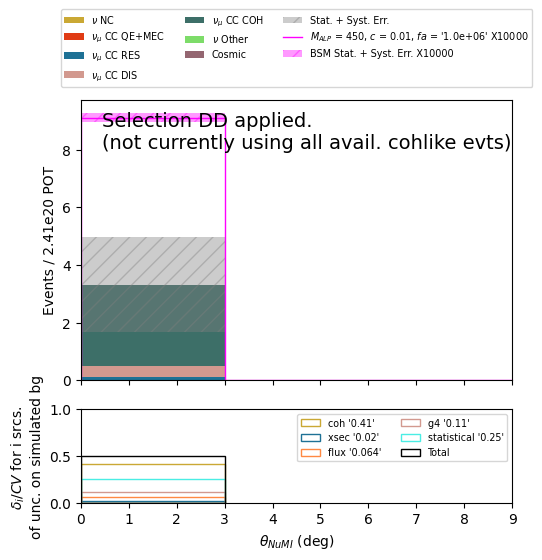

Total number of (POT-normalized) simulated background events in plot: '3.31'
Total uncertainty on simulated background events in plot: ±'1.64'
Total number of (POT-normalized) simulated signal events in plot: '0.00091'
Total uncertainty on simulated signal events in plot: ±'1.55e-05'


In [19]:
# October 31, 2025: to test updates
# same as cell below

# Theta NuMI with Benchmarked Event Selection

mccoh_syst_evtdfs=[0]
      
x = makeplot(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
         mccoh_syst_evtdfs, [0],
         (0,9.), bins=3,
         xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'Selection DD applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=10,
         bsm_detector_varis_vars=0,
         bsm_magnifier = 10000,
         evtSel_key='DD',
             do_detector_variations=False  
        )

VERIFY THAT THIS NUMBER IS THREE (2 cohlike samples + 1 nominal sample, for three different POT scalings):  3
[0.54968005 0.08116821 0.08677293]


/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  2


/tmp/ipykernel_1071966/3974722259.py:214: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
/tmp/ipykernel_1071966/3974722259.py:337: RuntimeWarning: invalid value encountered in divide
  pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov),
/tmp/ipykernel_1071966/3974722259.py:348: RuntimeWarning: invalid value encountered in divide
  p1.bar(bin_centers, mc_err/mc,
/tmp/ipykernel_1071966/3974722259.py:353: RuntimeWarning: invalid value encountered in divide
  print('Total percent uncertainty: \n', mc_err/mc)
/tmp/ipykernel_1071966/3974722259.py:382: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv.tot,
/tmp/ipykernel_1071966/3974722259.py:388: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


Total percent uncertainty: 
 [0.64592335        nan        nan]


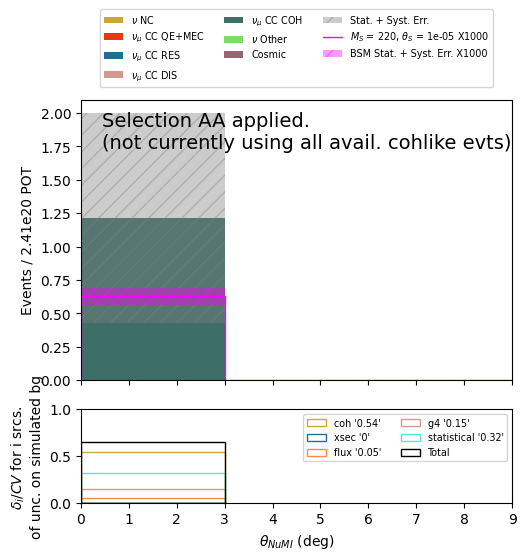

Total number of (POT-normalized) simulated background events in plot: '1.21'
Total uncertainty on simulated background events in plot: ±'0.784'
Total number of (POT-normalized) simulated signal events in plot: '0.000628'
Total uncertainty on simulated signal events in plot: ±'6.3e-05'


In [18]:
# Theta NuMI with Benchmarked Event Selection

mccoh_syst_evtdfs=[0]

#bsm_detector_varis_vars = []
#for bsm_sample in bsm_detector_varis_dfs:
#    this_samples_vars = []
#    for detect_variation_df in bsm_sample:
#        this_samples_vars.append(detect_variation_df.Snumi_angle_wgtByLen*180./math.pi)
#    bsm_detector_varis_vars.append(this_samples_vars)
        
x = makeplot(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi, #evtdf.Snumi_angle_wgtByLen*180./math.pi,
         mccoh_syst_evtdfs, [0], #[sdf.Snumi_angle_wgtByLen*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,9.), bins=3,
         xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'Selection AA applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=0, #bsm_detector_varis_vars,
         bsm_magnifier = 1000,
         evtSel_key='AA',
             do_detector_variations=False
        )

In [36]:
## Assume 20% detector uncertainty (same as Gray):

tot_AA = 1/np.sqrt(0.54**2 + 0.082**2 + 0.15**2 + 0.32**2)
print(tot_AA)


1.537145069027188


In [19]:
#print('Number of ALP events required for sensitivity for Selection AA, assuming unc_signal=30% and...')
limit_dir = '/exp/icarus/data/users/jdyer/muons_selections_study_2511/wCVwgts/'

print('Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.')

exp_limits_AA60 = np.load(limit_dir+'Selection_AA/pyhf_ExpLim_90CL_30uncSig_60uncBg.npy')
#print(exp_limits_AA)
#print(exp_limits_AA*11.)
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_AA60*11.]) + ']'
print('unc_bg=60%: ', formatted_arr_str)

exp_limits_AA75 = np.load(limit_dir+'Selection_AA/pyhf_ExpLim_90CL_30uncSig_75uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_AA75*11.]) + ']'
print('unc_bg=75%: ', formatted_arr_str)

exp_limits_AA100 = np.load(limit_dir+'Selection_AA/pyhf_ExpLim_90CL_30uncSig_100uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_AA100*11.]) + ']'
print('unc_bg=100%: ', formatted_arr_str)


#print('Number of ALP events required for sensitivity for Selection DD, assuming unc_signal=30% and...')
print('Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.')

exp_limits_DD60 = np.load(limit_dir+'Selection_DD/pyhf_ExpLim_90CL_30uncSig_60uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_DD60*11.]) + ']'
print('unc_bg=60%: ', formatted_arr_str)

exp_limits_DD75 = np.load(limit_dir+'Selection_DD/pyhf_ExpLim_90CL_30uncSig_75uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_DD75*11.]) + ']'
print('unc_bg=75%: ', formatted_arr_str)

exp_limits_DD100 = np.load(limit_dir+'Selection_DD/pyhf_ExpLim_90CL_30uncSig_100uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_DD100*11.]) + ']'
print('unc_bg=100%: ', formatted_arr_str)

print('The middle number of each list is the limit we would draw if the number of selected data events perfectly matches our central value expectation of number of selected background events, based on simulation.')
print('The numbers on either side are the limits we would draw if the number of selected data events is +2, +1, -1, or -2 sigma from our central value expectation of the number of selected background events, based on simulation.') 
#      our number of selected simulated background events.')


Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.
unc_bg=60%:  [1.10, 1.57, 2.66, 4.98, 9.68]
unc_bg=75%:  [1.10, 1.61, 2.71, 5.07, 9.80]
unc_bg=100%:  [1.12, 1.68, 2.83, 5.23, 10.04]
Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.
unc_bg=60%:  [1.65, 2.44, 3.89, 6.88, 12.68]
unc_bg=75%:  [1.78, 2.57, 4.07, 7.09, 12.98]
unc_bg=100%:  [1.98, 2.75, 4.32, 7.44, 13.45]
The middle number of each list is the limit we would draw if the number of selected data events perfectly matches our central value expectation of number of selected background events, based on simulation.
The numbers on either side are the limits we would draw if the number of selected data events is +2, +1, -1, or -2 sigma from our central value expectation of the number of selected background events, based on simulation.


/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_pe

/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_pe

/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_pe

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


/tmp/ipykernel_671138/3690885382.py:199: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)


Combined result minus separate result: 
 [            nan  6.24967734e-06 -7.33915330e-04 -2.82402115e-03
  6.50562600e-05  3.58516356e-02  2.30864988e-03  3.02486701e-04
             nan             nan             nan             nan
             nan             nan             nan             nan
             nan             nan             nan             nan
             nan             nan             nan             nan
             nan]


/tmp/ipykernel_671138/3690885382.py:330: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv,
/tmp/ipykernel_671138/3690885382.py:336: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


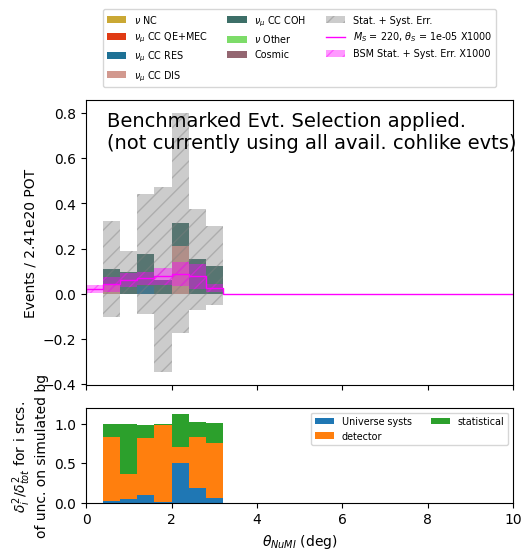

Total number of (POT-normalized) simulated background events in plot: '1.03'
Total uncertainty on simulated background events in plot: ±'0.781'
Total number of (POT-normalized) simulated signal events in plot: '0.00046'
Total uncertainty on simulated signal events in plot: ±'0.000104'


In [17]:
# Theta NuMI with Benchmarked Event Selection

bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.Snumi_angle_wgtByLen*180./math.pi)
    bsm_detector_varis_vars.append(this_samples_vars)
        
x = makeplot(evtdf, evtdf.Snumi_angle_wgtByLen*180./math.pi,
         mccoh_syst_evtdfs, [sdf.Snumi_angle_wgtByLen*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,9.), bins=3,
         xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'Benchmarked Evt. Selection applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 1000,
         evtSel_key='I'
        )

In [28]:
for c in make_categories(evtdf, detailed_bsm=True):
    print(c.name)

$M_S$ = 220, $\theta_S$ = 1e-05
$M_S$ = 240, $\theta_S$ = 1e-05
$M_S$ = 260, $\theta_S$ = 1e-05
$M_S$ = 280, $\theta_S$ = 1e-05
$M_S$ = 300, $\theta_S$ = 1e-05
$M_S$ = 320, $\theta_S$ = 1e-05
$M_S$ = 340, $\theta_S$ = 1e-05
$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 340, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'
$\nu$ NC
$\nu_\mu$ CC QE+MEC
$\nu_\mu$ CC RES
$\nu_\mu$ CC DIS
$\nu_\mu$ CC COH
$\nu$ Other
Cosmic


VERIFY THAT THIS NUMBER IS THREE (2 cohlike samples + 1 nominal sample, for three different POT scalings):  3
[0.54968005 0.08116821 0.08677293]


/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  3
Total percent uncertainty: 
 [0.49647483 0.41869719 0.40873511 0.39708397 0.42547573 0.46616929
 0.52663853 0.78022757 1.14713454 0.71486856]


/tmp/ipykernel_1071966/3974722259.py:382: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv.tot,
/tmp/ipykernel_1071966/3974722259.py:388: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


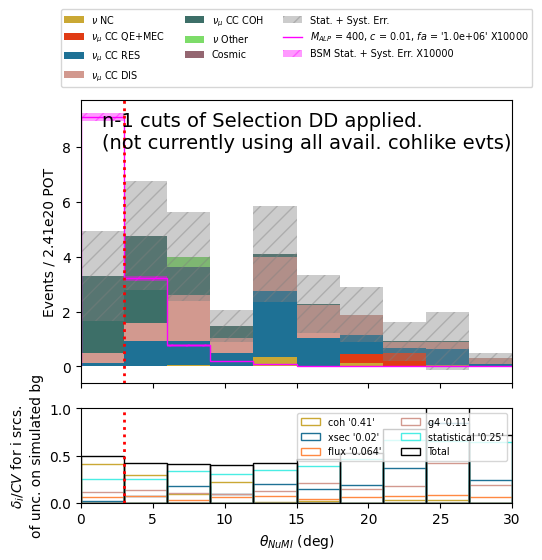

Total number of (POT-normalized) simulated background events in plot: '24'
Total uncertainty on simulated background events in plot: ±'4.07'
Total number of (POT-normalized) simulated signal events in plot: '0.00134'
Total uncertainty on simulated signal events in plot: ±'1.88e-05'


In [32]:
# Explore Sideband Defined as Flipped theta_NuMI

mccoh_syst_evtdfs=[0]
      
x = makeplot(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
         mccoh_syst_evtdfs, [0],
         (0,30.), bins=10, vline=[3.],
         xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'n-1 cuts of Selection DD applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=10,
         bsm_detector_varis_vars=0,
         bsm_magnifier = 10000,
         evtSel_key='J',
             do_detector_variations=False  
        )

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


/tmp/ipykernel_4091925/3186042509.py:274: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv,
/tmp/ipykernel_4091925/3186042509.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


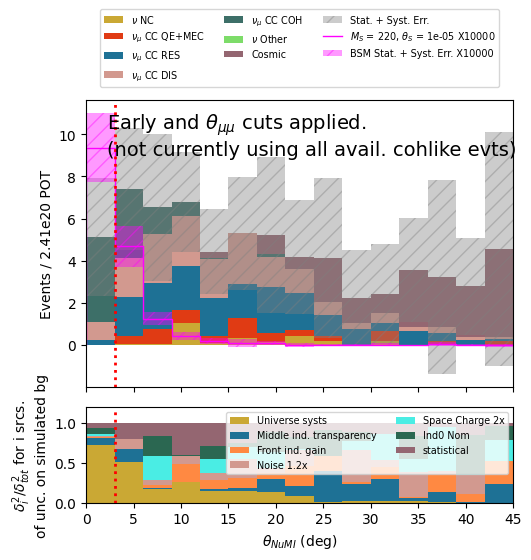

Total number of (POT-normalized) simulated background events in plot: '67.9'
Total uncertainty on simulated background events in plot: ±'46'
Total number of (POT-normalized) simulated signal events in plot: '0.00163'
Total uncertainty on simulated signal events in plot: ±'0.000395'


In [45]:
# Explore Sideband Defined as Flipped theta_NuMI

bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.Snumi_angle_wgtByLen*180./math.pi)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.Snumi_angle_wgtByLen*180./math.pi,
         mccoh_syst_evtdfs, [sdf.Snumi_angle_wgtByLen*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,45.), bins=15, vline=[3.], xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'Early and $\\theta_{\mu\mu}$ cuts applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 10000,
         evtSel_key='J'
        )

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


/tmp/ipykernel_4091925/3186042509.py:274: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv,
/tmp/ipykernel_4091925/3186042509.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


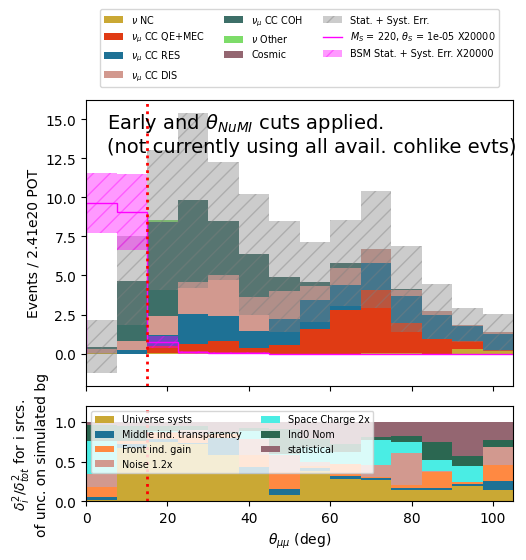

Total number of (POT-normalized) simulated background events in plot: '70.3'
Total uncertainty on simulated background events in plot: ±'41.7'
Total number of (POT-normalized) simulated signal events in plot: '0.00098'
Total uncertainty on simulated signal events in plot: ±'0.00025'


In [44]:
# Explore Sideband Defined as Flipped theta_mumu

bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.opening_angle*180./math.pi)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.opening_angle*180./math.pi,
         mccoh_syst_evtdfs, [sdf.opening_angle*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,105.), bins=14, vline=[15.], xlabel = "$\\theta_{\mu\mu}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_mumu',
         textOnPlot = 'Early and $\\theta_{NuMI}$ cuts applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 20000,
         evtSel_key='K'
        )


/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


/tmp/ipykernel_4091925/3186042509.py:160: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
/tmp/ipykernel_4091925/3186042509.py:274: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv,
/tmp/ipykernel_4091925/3186042509.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


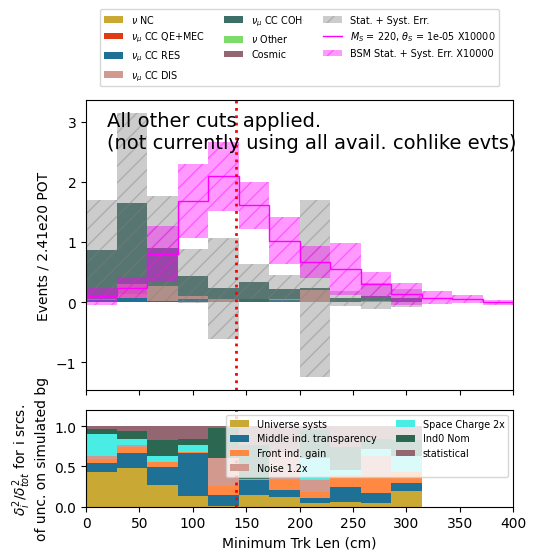

Total number of (POT-normalized) simulated background events in plot: '5.11'
Total uncertainty on simulated background events in plot: ±'6.96'
Total number of (POT-normalized) simulated signal events in plot: '0.000934'
Total uncertainty on simulated signal events in plot: ±'0.000403'


In [52]:
# Explore Sideband wrt Track Length

bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.shorter_track_length)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.shorter_track_length,
         mccoh_syst_evtdfs, [sdf.shorter_track_length for sdf in mccoh_syst_evtdfs],
         (0,400.), bins=14, vline=[140.0], xlabel = "Minimum Trk Len (cm)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='trkLen',
         textOnPlot = 'All other cuts applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 10000,
         evtSel_key='L'
        )

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2
[0.49176854 0.8075605  0.74406262 0.84588782 0.89228598 0.69068775
 0.92026143 0.85284937 0.76131278 0.927426   0.76602507 0.78192853
 0.77062276 0.50531138 0.60504579 0.32509903 0.31621652 0.2829482
 0.17605485 0.13559829 0.17334051 0.0534051  0.03923725 0.00585867
 0.0040233 ]
running sum:
[0.49176854 0.8075605  0.74406262 0.84588782 0.89228598 0.69068775
 0.92026143 0.85284937 0.76131278 0.927426   0.76602507 0.78192853
 0.77062276 0.50531138 0.60504579 0.32509903 0.31621652 0.2829482
 0.17605485 0.13559829 0.17334051 0.0534051  0.03923725 0.00585867
 0.0040233 ]
[0.00934477 0.04964293 0.02496197 0.0448164  0.03448711 0.0116307
 0.01161154 0.03940166 0.03179028 0.01441734 0.07084711 0.03851696
 0.08997049 0.056914   0.09368903 0.05640642 0.15994491 0.18646117
 0.07195568 0.27802487 0.35141691 0.24085815 0.18425634 0.21809734
 0.31742622]
running sum:
[0.50111331 0.85720344 0.7690

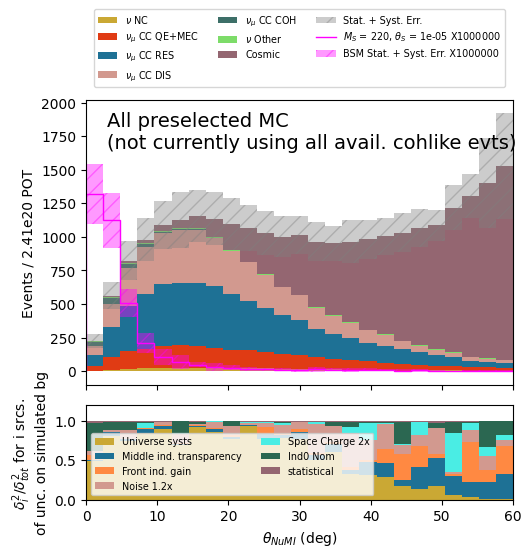

Total number of (POT-normalized) simulated background events in plot: '2.58e+04'
Total uncertainty on simulated background events in plot: ±'4.23e+03'
Total number of (POT-normalized) simulated signal events in plot: '0.00356'
Total uncertainty on simulated signal events in plot: ±'0.000935'


In [66]:
bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.Snumi_angle_wgtByLen*180./math.pi)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.Snumi_angle_wgtByLen*180./math.pi,
         mccoh_syst_evtdfs, [sdf.Snumi_angle_wgtByLen*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,60.), xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'All preselected MC \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 1000000
        )

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


UnboundLocalError: local variable 'middle_ind_cov' referenced before assignment

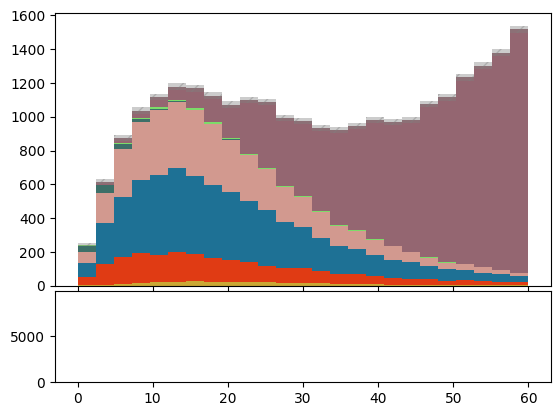

In [22]:
makeplot(evtdf, evtdf.Snumi_angle_mcs*180./math.pi,
         mccoh_syst_evtdfs, [sdf.Snumi_angle_mcs*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,60.), xlabel = "MCS $\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI', 
         textOnPlot = 'All preselected MC \n(not currently using all avail. cohlike evts)',
        do_systs=False)

In [ ]:
# TODO: bottom panel: show uncert. squared (then I can show breakdown of contributing types.)
# To get model systematics: 

# what's my goal? Make a plot that shows:
# DONE - neutrinos, stacked by type, with total uncertainty
# - bsm benchmark(s) that are given (single or a list), plotted as line hist, with total uncertainty
# - (to be added later: ) data as data points, with statistical error
# - bottom panel shows breakdown of fractional uncertainty for each type of uncertainty, in each bin, as stacked hist.

# plot inputs:
# - nu_evtdf (concatenated from nominal nu df and cohlike dfs)
# - cohlike_evtdfs
# - bsm_df (one df per benchmark mass you want to plot)
# - list of sets (list of lists) of bsm detector variations 

In [44]:
print(len(soladero))

7


In [ ]:
# ma_300_syst_evtdfs, ma_300_syst_hdrs = extract_detVar_dfs("ma_300")

In [25]:
for df in ma_300_syst_evtdfs: 
    print(df.shape)
df = ma_300_syst_evtdfs[0]
for c in df.columns: print(c)
#plt.hist(df.Snumi_angle_wgtByLen*180/math.pi, 20)
#plt.show()

(165, 798)
(149, 798)
(172, 798)
(150, 798)
(165, 798)
(161, 798)
(145, 798)
('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('slc', 'truth', 'iscc', '', '', '')

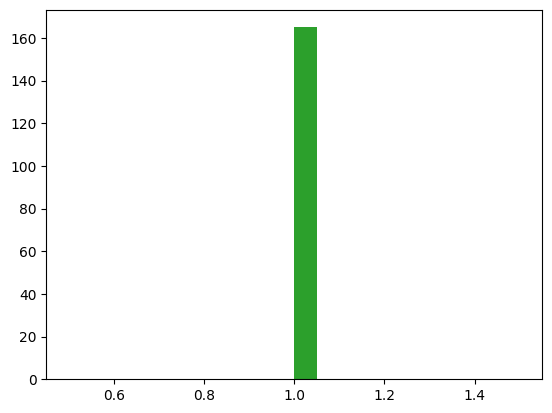

In [27]:
plt.hist(df.wgt.cv, 20)
plt.hist(df.wgt.concrete.cv, 20)
plt.hist(df.wgt.coh.cv, 20)
plt.show()